In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
import datetime
from datetime import date, timedelta, time
import requests
from IPython.core.pylabtools import figsize
from bs4 import BeautifulSoup
from time import sleep
import random
import string
import markdown
import nltk
from markdown import markdown
from scipy import stats as st
from scipy.stats import shapiro, ttest_ind, levene, chi2_contingency, mannwhitneyu
from IPython.display import Markdown
from nltk.corpus import stopwords
import re

from spyder_kernels.utils.lazymodules import scipy
from wordcloud import WordCloud
from collections import Counter
from nltk import bigrams, trigrams
from nltk.tokenize import word_tokenize
import pymorphy3

# Настройки
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format
warnings.filterwarnings('ignore')

# Загрузка стоп-слов
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dariakay/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/dariakay/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/dariakay/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Загрузка данных

In [2]:
url = 'https://drive.google.com/uc?export=download&id=1MxdpvJUuOTgLRZYOQkA5ZSCosEj45C-P'

df = pd.read_csv(url, delimiter='\t', header=None, names=['col'])
df[['label', 'comment']] = df['col'].str.split(n=1, expand=True)
df = df.drop('col', axis=1)
display(df.head())

,label,comment
0,__label__INSULT,скотина! что сказать
1,__label__NORMAL,я сегодня проезжала по рабочей и между домами ...
2,__label__NORMAL,очередной лохотрон. зачем придумывать очередно...
3,__label__NORMAL,"ретро дежавю ... сложно понять чужое сердце , ..."
4,__label__NORMAL,а когда мы статус агрогородка получили?


## 1. Проверка качества данных

### 1.1 Описание данных

In [3]:
shape = df.shape
print('Размер данных:', shape)

Размер данных: (248290, 2)


In [4]:
display(df.describe(include='all'))

,label,comment
count,248290,248290
unique,8,248289
top,__label__NORMAL,с днем рождения
freq,203685,2


### 1.2 Проверка пропусков

In [5]:
print('Количество пропусков по столбцам:')
print(df.isnull().sum(), end='\n\n')
print('=================================', end='\n\n')
print(df.info())

Количество пропусков по столбцам:
label      0
comment    0
dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248290 entries, 0 to 248289
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   label    248290 non-null  object
 1   comment  248290 non-null  object
dtypes: object(2)
memory usage: 3.8+ MB
None


### 1.3 Наличие дубликатов среди комментариев

Из п. 1.1 видно, что среди общего количества комментариев есть только один неуникальный комментарий "с днем рождения", встречающийся два раза

### Выводы:
- в датасете почти 250 тыс. комментариев
- нет пропусков
- все комментарии в нижнем регистре
- есть только один дублирующийся комментарий
- самый частый класс - нормальный комментарий

## 2. Сбалансированность классов

In [6]:
pivot = df.groupby(['label']).count().sort_values(by='comment', ascending=False)
pivot = pivot.rename(columns={'comment': 'количество'})

pivot['доля, %'] = (pivot['количество'] / shape[0] * 100).round(1)

pivot_formated = pivot.style.format({'количество': '{:,}', 'доля, %': '{:.1f}%'
                                     }).background_gradient(subset=['доля, %'])

display(pivot_formated)

,количество,"доля, %"
label,,
__label__NORMAL,"203,685",82.0%
__label__INSULT,"28,567",11.5%
"__label__INSULT,__label__THREAT","6,317",2.5%
__label__THREAT,"5,460",2.2%
__label__OBSCENITY,"2,245",0.9%
"__label__INSULT,__label__OBSCENITY","1,766",0.7%
"__label__INSULT,__label__OBSCENITY,__label__THREAT",176,0.1%
"__label__OBSCENITY,__label__THREAT",74,0.0%


Чтобы к каждому комментарию относился один label, назначим для них приоритет по важности. Так, **__label__OBSCENITY** будет приоритетнее, чем **__label__THREAT**, а он в свою очередь приоритетнее, чем **__label__INSULT**

Приоритеты заданы таким образом, чтобы доля редких классов немного увеличилась

In [7]:
df['label'] = df['label'].apply(lambda x: '__label__OBSCENITY' if '__label__OBSCENITY' in x else x)
df['label'] = df['label'].apply(lambda x: '__label__THREAT' if '__label__THREAT' in x else x)
df['label'] = df['label'].apply(lambda name: re.sub("__label__", "", name))

categories = df['label'].value_counts().sort_values(ascending=True).index
categories

Index(['OBSCENITY', 'THREAT', 'INSULT', 'NORMAL'], dtype='object', name='label')

In [8]:
pivot = df.groupby(['label']).count().sort_values(by='comment', ascending=False)
pivot = pivot.rename(columns={'comment': 'количество'})

pivot['доля, %'] = (pivot['количество'] / shape[0] * 100).round(1)

pivot_formated = pivot.style.format({'количество': '{:,}', 'доля, %': '{:.1f}%'
                                     }).background_gradient(subset=['доля, %'])

display(pivot_formated)

,количество,"доля, %"
label,,
NORMAL,"203,685",82.0%
INSULT,"28,567",11.5%
THREAT,"11,777",4.7%
OBSCENITY,"4,261",1.7%


### Выводы:
- доля нетоксичных комментариев больше 80%

- данные сильно несбалансированны, это необходимо будет учитывать при создание моделей

- теперь каждый комментарий относится только к одному классу

## 3. Статистический анализ

### 3.1 Добавляем признаки

In [9]:
# Убираем стоп-слова
stopwords_set = set(stopwords.words('russian'))
print(f'Загружено русских стоп-слов: {len(stopwords_set)}')
print('Стоп-слова:')
print(sorted(list(stopwords_set)))

Загружено русских стоп-слов: 151
Стоп-слова:
['а', 'без', 'более', 'больше', 'будет', 'будто', 'бы', 'был', 'была', 'были', 'было', 'быть', 'в', 'вам', 'вас', 'вдруг', 'ведь', 'во', 'вот', 'впрочем', 'все', 'всегда', 'всего', 'всех', 'всю', 'вы', 'где', 'да', 'даже', 'два', 'для', 'до', 'другой', 'его', 'ее', 'ей', 'ему', 'если', 'есть', 'еще', 'ж', 'же', 'за', 'зачем', 'здесь', 'и', 'из', 'или', 'им', 'иногда', 'их', 'к', 'как', 'какая', 'какой', 'когда', 'конечно', 'кто', 'куда', 'ли', 'лучше', 'между', 'меня', 'мне', 'много', 'может', 'можно', 'мой', 'моя', 'мы', 'на', 'над', 'надо', 'наконец', 'нас', 'не', 'него', 'нее', 'ней', 'нельзя', 'нет', 'ни', 'нибудь', 'никогда', 'ним', 'них', 'ничего', 'но', 'ну', 'о', 'об', 'один', 'он', 'она', 'они', 'опять', 'от', 'перед', 'по', 'под', 'после', 'потом', 'потому', 'почти', 'при', 'про', 'раз', 'разве', 'с', 'сам', 'свою', 'себе', 'себя', 'сейчас', 'со', 'совсем', 'так', 'такой', 'там', 'тебя', 'тем', 'теперь', 'то', 'тогда', 'того', 'тож

In [10]:
# Очищаем столбец comment от стоп-слов и лишних символов
def clean_comment(text):
    regex = re.compile('[a-zA-Zа-яА-ЯёЁ_-]+')
    words = regex.findall(text)

    filtered_words = [
        word for word in words
        if word not in stopwords_set and len(word) > 1
    ]

    return ' '.join(filtered_words)


# Применяем очистку
df['cleaned_comment'] = df['comment'].apply(clean_comment)

In [11]:
# Очищаем столбец comment ТОЛЬКО ОТ лишних символов
def comment_without_punct(text):
    regex = re.compile('[a-zA-Zа-яА-ЯёЁ_-]+')
    words = regex.findall(str(text))

    return ' '.join(words)


# Применяем очистку
df['comment_without_punct'] = df['comment'].apply(comment_without_punct)
df.head()

,label,comment,cleaned_comment,comment_without_punct
0,INSULT,скотина! что сказать,скотина сказать,скотина что сказать
1,NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,я сегодня проезжала по рабочей и между домами ...
2,NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...
3,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...
4,NORMAL,а когда мы статус агрогородка получили?,статус агрогородка получили,а когда мы статус агрогородка получили


Добавляем столбцы для анализа: **length_sym** - кол-во символов в изначальном комментарии; **length_words** - кол-во слов в комментарии без лишних символов; **av_word_len** - средняя длина слов в комментарии без лишних символов

In [12]:
df['length_sym'] = df['comment'].apply(lambda x: len(x))

df['length_words'] = df['comment_without_punct'].apply(lambda x: len(x.split()))

y = df['comment_without_punct'].apply(lambda x: x.split())


def av_len_of_words(lst):
    a = []
    for el in lst:
        a.append(len(el))
    return np.mean(a)


df['av_word_len'] = df['comment_without_punct'].apply(lambda x: x.split()).apply(av_len_of_words)
df

,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len
0,INSULT,скотина! что сказать,скотина сказать,скотина что сказать,20,3,5.67
1,NORMAL,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,я сегодня проезжала по рабочей и между домами ...,180,28,5.21
2,NORMAL,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,очередной лохотрон зачем придумывать очередной...,379,54,5.78
3,NORMAL,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,ретро дежавю сложно понять чужое сердце лиш ощ...,72,10,5.70
4,NORMAL,а когда мы статус агрогородка получили?,статус агрогородка получили,а когда мы статус агрогородка получили,39,6,5.50
...,...,...,...,...,...,...,...
248285,NORMAL,правильно всё по пять (5)...,правильно всё пять,правильно всё по пять,28,4,4.50
248286,INSULT,ёбанные нубы заходите на сервер мой ник _creep...,ёбанные нубы заходите сервер ник _creepro пвп ...,ёбанные нубы заходите на сервер мой ник _creep...,143,23,5.26
248287,NORMAL,а у меня наверное рекорд в 1962 году в училище...,наверное рекорд году училище коренной зуб возм...,а у меня наверное рекорд в году в училище коре...,188,30,4.83
248288,NORMAL,спасибо всем большое),спасибо всем большое,спасибо всем большое,21,3,6.00


In [13]:
# Рассмотрим распределение этих столбцов в зависимости от типа комментария (комментарии с меткой '__label__NORMAL' и все остальные)
df['is_normal'] = (df['label'] == 'NORMAL')
cols = ['length_sym', 'length_words', 'av_word_len']

normal_stats = df[df['is_normal']][cols].describe()
non_normal_stats = df[~df['is_normal']][cols].describe()
all_stats = df[cols].describe()

result = pd.concat({
    'Non-Normal': non_normal_stats,
    'Normal': normal_stats,
    'All Data': all_stats
}, axis=1)

display(result)

Non-Normal                              Normal                           \
      length_sym length_words av_word_len length_sym length_words av_word_len   
count  44,605.00    44,605.00   44,605.00 203,685.00   203,685.00  203,685.00   
mean       81.41        13.37        5.12      77.37        12.40        5.17   
std        92.28        15.15        1.24      97.25        15.59        1.45   
min         4.00         1.00        1.17       2.00         1.00        1.00   
25%        30.00         5.00        4.36      27.00         4.00        4.33   
50%        52.00         9.00        4.93      46.00         7.00        5.00   
75%        96.00        16.00        5.60      86.00        14.00        5.75   
max       998.00       174.00       40.00     998.00       267.00      215.00   

        All Data                           
      length_sym length_words av_word_len  
count 248,290.00   248,290.00  248,290.00  
mean       78.10        12.58        5.16  
std        96.39        15.52        1.41  
min         2.00         1.00        1.00  
25%        27.00         4.00        4.33  
50%        47.00         8.00        5.00  
75%        88.00        14.00        5.71  
max       998.00       267.00      215.00

In [14]:
# Рассмотрим распределение столбцов в зависимости от конкретного класса
cols = ['length_sym', 'length_words', 'av_word_len']

normal_stats = df[df['is_normal']][cols].describe()
insult_stats = df[df['label'] == 'INSULT'][cols].describe()
threat_stats = df[df['label'] == 'THREAT'][cols].describe()
obscenity_stats = df[df['label'] == 'OBSCENITY'][cols].describe()

result = pd.concat({
    'Normal': normal_stats,
    'Insult': insult_stats,
    'Threat': threat_stats,
    'Obscenity': obscenity_stats
}, axis=1)

display(result)

Normal                              Insult                           \
      length_sym length_words av_word_len length_sym length_words av_word_len   
count 203,685.00   203,685.00  203,685.00  28,567.00    28,567.00   28,567.00   
mean       77.37        12.40        5.17      88.55        14.44        5.18   
std        97.25        15.59        1.45     101.09        16.57        1.25   
min         2.00         1.00        1.00       4.00         1.00        1.17   
25%        27.00         4.00        4.33      31.00         5.00        4.41   
50%        46.00         7.00        5.00      56.00         9.00        5.00   
75%        86.00        14.00        5.75     105.00        17.00        5.67   
max       998.00       267.00      215.00     998.00       174.00       40.00   

          Threat                           Obscenity                           
      length_sym length_words av_word_len length_sym length_words av_word_len  
count  11,777.00    11,777.00   11,777.00   4,261.00     4,261.00    4,261.00  
mean       69.09        11.33        5.17      67.56        11.79        4.60  
std        71.20        11.74        1.23      75.23        12.71        1.05  
min         5.00         1.00        1.71       4.00         1.00        1.75  
25%        29.00         5.00        4.42      26.00         5.00        4.00  
50%        47.00         8.00        5.00      43.00         8.00        4.50  
75%        81.00        13.00        5.65      79.00        14.00        5.11  
max       970.00       152.00       20.00     850.00       147.00       23.00

### 3.2 Анализ выбросов

In [15]:
# Получили довольно странное значение по максимальной средней длине слов (215)
# Проверим, какие комментарии имеют неправдоподобную среднююю длину слов
df[df['av_word_len'] >= 35]

,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len,is_normal
3655,NORMAL,шшашшшшшшшщщщззхгпгрпшогрпркпгмгпнмниерннеп5пн...,шшашшшшшшшщщщззхгпгрпшогрпркпгмгпнмниерннеп пн...,шшашшшшшшшщщщззхгпгрпшогрпркпгмгпнмниерннеп пн...,79,2,39.00,True
8697,NORMAL,класснаялицоипопазачемвсемпоказываешьпустьразд...,класснаялицоипопазачемвсемпоказываешьпустьразд...,класснаялицоипопазачемвсемпоказываешьпустьразд...,60,1,60.00,True
56039,NORMAL,всеперекопалиулицуорджоникидзенаостоновкахноги...,всеперекопалиулицуорджоникидзенаостоновкахноги...,всеперекопалиулицуорджоникидзенаостоновкахноги...,55,1,54.00,True
57714,NORMAL,и-по-ушам-не-забывает-коту-проехать,и-по-ушам-не-забывает-коту-проехать,и-по-ушам-не-забывает-коту-проехать,35,1,35.00,True
167437,NORMAL,ююююююбююююююююбююбююбюббюббббюббюбюббббюббббб...,ююююююбююююююююбююбююбюббюббббюббюбюббббюббббб...,ююююююбююююююююбююбююбюббюббббюббюбюббббюббббб...,150,1,150.00,True
168378,NORMAL,иапрвппвпрекннуннкнприарвпаприариаврпрпрмисиси...,иапрвппвпрекннуннкнприарвпаприариаврпрпрмисиси...,иапрвппвпрекннуннкнприарвпаприариаврпрпрмисиси...,215,1,215.00,True
178726,NORMAL,приветтелкакаутебядиладавайжитьвмес,приветтелкакаутебядиладавайжитьвмес,приветтелкакаутебядиладавайжитьвмес,35,1,35.00,True
186019,NORMAL,амнезавасграмотных толкутоотвашейграмотынаучил...,амнезавасграмотных толкутоотвашейграмотынаучил...,амнезавасграмотных толкутоотвашейграмотынаучил...,103,2,51.00,True
190009,INSULT,уродищееееееееееееееееееееееееееееееееее,уродищееееееееееееееееееееееееееееееееее,уродищееееееееееееееееееееееееееееееееее,40,1,40.00,False


In [16]:
# Такие комментарии не имеют содержательного смысла, поэтому будем считать их выбросами и удалим из выборки
df = df[df['av_word_len'] < 35].reset_index(drop=True)

In [17]:
# Добавим проверку на содержание матерных слов в сообщении
# Для этого используем regex паттерн, который достаточно хорошо определяет матерные слова

swearing_pattern = "(?iu)(?<![а-яё])(?:(?:(?:у|[нз]а|(?:хитро|не)?вз?[ыьъ]|с[ьъ]|(?:и|ра)[зс]ъ?|(?:о[тб]|п[оа]д)[ьъ]?|(?:\S(?=[а-яё]))+?[оаеи-])-?)?(?:[её](?:б(?!о[рй]|рач)|п[уа](?:ц|тс))|и[пб][ае][тцд][ьъ]).*?|(?:(?:н[иеа]|(?:ра|и)[зс]|[зд]?[ао](?:т|дн[оа])?|с(?:м[еи])?|а[пб]ч|в[ъы]?|пр[еи])-?)?ху(?:[яйиеёю]|л+и(?!ган)).*?|бл(?:[эя]|еа?)(?:[дт][ьъ]?)?|\S*?(?:п(?:[иеё]зд|ид[аое]?р|ед(?:р(?!о)|[аое]р|ик)|охую)|бля(?:[дбц]|тс)|[ое]ху[яйиеё]|хуйн).*?|(?:о[тб]?|про|на|вы)?м(?:анд(?:[ауеыи](?:л(?:и[сзщ])?[ауеиы])?|ой|[ао]в.*?|юк(?:ов|[ауи])?|е[нт]ь|ища)|уд(?:[яаиое].+?|е?н(?:[ьюия]|ей))|[ао]л[ао]ф[ьъ](?:[яиюе]|[еёо]й))|елд[ауые].*?|ля[тд]ь|(?:[нз]а|по)х)(?![а-яё])"
df["swearing"] = df["comment"].apply(lambda text: bool(re.search(swearing_pattern, text)))

In [18]:
# Теперь добавим проверку на содержание разных видов эмодзи в датасете
# Сделаем для каждого эмодзи отдельные колонки


positive_emoji_pattern_chgpt = re.compile(
    u'['
    u'\U0001F600-\U0001F64F'  # смайлы (улыбки, радость, обнимашки и т.п.)
    u'\U0001F44D'              # 👍 палец вверх
    u'\U0001F44C'              # 👌 всё ок
    u'\U0001F64C'              # 🙌 поднятые руки
    u'\u270A-\u270D'           # ✊✋✌ жесты руками
    u'\U0001F929'              # 🤩 восторг
    u'\U0001F973'              # 🥳 праздник
    u'\u2764\uFE0F'            # ❤️ сердце
    u'\U0001F49A-\U0001F49F'   # 💚💛💜💗 и т.п.
    u'\U0001F607'              # 😇 нимб
    u'\U0001F4AA'              # 💪 сила
    u'\U0001F44F'              # 👏 аплодисменты
    u']'
)

negative_emoji_pattern_chgpt = re.compile(
    u'['
    u'\U0001F44E'  # 👎 палец вниз
    u'\U0001F621'  # 😡 злость
    # u'\U0001F620'  # 😠 сердитый
    # u'\U0001F624'  # 😤 раздражение
    u'\U0001F92C'  # 🤬 матерный
    u'\U0001F4A9'  # 💩 "говно"
    # u'\U0001F494'  # 💔 разбитое сердце
    u']'
)

adult_emoji_pattern_chgpt = re.compile(
    u'['
    u'\U0001F346'  # 🍆 баклажан
    u'\U0001F351'  # 🍑 персик
    u'\U0001F34C'  # 🍌 банан
    u'\U0001F445'  # 👅 язык
    # u'\U0001F48B'  # 💋 поцелуй
    u'\U0001F4A6'  # 💦 капельки
    u']'
)

df["has_positive_emoji"] = df["comment"].apply(
    lambda text: bool(re.search(positive_emoji_pattern_chgpt, str(text)))
)
df["has_negative_emoji"] = df["comment"].apply(
    lambda text: bool(re.search(negative_emoji_pattern_chgpt, str(text)))
)
df["has_obscene_emoji"] = df["comment"].apply(
    lambda text: bool(re.search(adult_emoji_pattern_chgpt, str(text)))
)


In [19]:
counts = df.groupby(["label", "swearing"]).size().unstack(fill_value=0) 
counts.columns = counts.columns.astype(int)
print("\nCounts (label x swearing):")
display(counts)

percent_within_label = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2)
print("\nПроцент (внутри label) — доля с/без мата (в %):")
display(percent_within_label)

counts_by_swearing = counts.T
percent_within_swearing = (counts_by_swearing.div(counts_by_swearing.sum(axis=1), axis=0) * 100).round(2)
print("\nПроцент (внутри swearing) — распределение по label (в %):")
display(percent_within_swearing.T) 


print("\nОтношение swearing к is_normal")
pd.crosstab(df['is_normal'], df['swearing'])


Counts (label x swearing):


swearing,0,1
label,,
INSULT,12491,16075
NORMAL,203313,364
OBSCENITY,2373,1888
THREAT,9209,2568



Процент (внутри label) — доля с/без мата (в %):


swearing,0,1
label,,
INSULT,43.73,56.27
NORMAL,99.82,0.18
OBSCENITY,55.69,44.31
THREAT,78.19,21.81



Процент (внутри swearing) — распределение по label (в %):


swearing,0,1
label,,
INSULT,5.49,76.93
NORMAL,89.41,1.74
OBSCENITY,1.04,9.04
THREAT,4.05,12.29



Отношение swearing к is_normal


swearing,False,True
is_normal,,
False,24073,20531
True,203313,364


### 3.3 Проводим статистические тесты

In [20]:
#Проверим на нормальность
def normal(df, column, group_column='is_normal', alpha=0.05):
    group1 = df[df[group_column]][column]
    group2 = df[~df[group_column]][column]

    p1 = shapiro(group1)
    p2 = shapiro(group2)

    print(f'Нормальность (Shapiro): Group1 p={p1[1]}, Group2 p={p2[1]}')
    a = 'ненормально' if p1[1] < alpha else 'нормально'
    b = 'ненормально' if p2[1] < alpha else 'нормально'
    print(f'Распределение нетоксичных комментариев {a}. Распределение токсичных комментариев {b}')


display(Markdown('**Гипотезы для проверки на нормальность:**'))
print('H0: Распределение является нормальным')
print('Ha: Распределение не является нормальным')

display(Markdown('**Количество символов в комментарии:**'))
normal(df, 'length_sym')

display(Markdown('**Количество слов в комментарии:**'))
normal(df, 'length_words')

display(Markdown('**Средняя длина слов в комментарии:**'))
normal(df, 'av_word_len')

**Гипотезы для проверки на нормальность:**

H0: Распределение является нормальным
Ha: Распределение не является нормальным


**Количество символов в комментарии:**

Нормальность (Shapiro): Group1 p=1.0221576787173631e-171, Group2 p=1.5680294444242127e-128
Распределение нетоксичных комментариев ненормально. Распределение токсичных комментариев ненормально


**Количество слов в комментарии:**

Нормальность (Shapiro): Group1 p=4.570690066614381e-171, Group2 p=6.935870812213868e-128
Распределение нетоксичных комментариев ненормально. Распределение токсичных комментариев ненормально


**Средняя длина слов в комментарии:**

Нормальность (Shapiro): Group1 p=1.4655424747290944e-124, Group2 p=2.1093896786171487e-97
Распределение нетоксичных комментариев ненормально. Распределение токсичных комментариев ненормально


Несмотря на ненормальное распределение данных, t-test можно применять при большом кол-ве наблюдений

In [21]:
# Проверка равенства дисперсий и использование двустороннего t-test для проверки равенства средних
def compare_means(df, column, group_column='is_normal', alpha=0.05):
    group1 = df[df[group_column]][column]
    group2 = df[~df[group_column]][column]

    print(f'Размеры выборок: {len(group1)} vs {len(group2)}')
    print(f'Средние: {group1.mean():.2f} vs {group2.mean():.2f}')

    stat, p_levene = levene(group1, group2)
    if p_levene < 0.05:
        print("Дисперсии неравны - используем Welch's t-test")
        t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
    else:
        print('Дисперсии равны - используем standard t-test')
        t_stat, p_value = ttest_ind(group1, group2, equal_var=True)

    print(f'T-test: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}')

    if p_value < alpha:
        print('Статистически значимые различия есть (p < 0.05)')
    else:
        print('Статистически значимых различий нет (p ≥ 0.05)')


display(Markdown('**Гипотезы для проверки равенства дисперсий:**'))
print('H0: σ₁² = σ₂² (дисперсии равны)')
print('Ha: σ₁² != σ₂² (дисперсии не равны)')

display(Markdown('**Гипотезы для проверки равенства средних:**'))
print('H0: μ₁ = μ₂')
print('Ha: μ₁ != μ₂')

display(Markdown('**Количество символов в комментарии:**'))
compare_means(df, 'length_sym')

display(Markdown('**Количество слов в комментарии:**'))
compare_means(df, 'length_words')

display(Markdown('**Средняя длина слов в комментарии:**'))
compare_means(df, 'av_word_len')

**Гипотезы для проверки равенства дисперсий:**

H0: σ₁² = σ₂² (дисперсии равны)
Ha: σ₁² != σ₂² (дисперсии не равны)


**Гипотезы для проверки равенства средних:**

H0: μ₁ = μ₂
Ha: μ₁ != μ₂


**Количество символов в комментарии:**

Размеры выборок: 203677 vs 44604
Средние: 77.37 vs 81.41
Дисперсии неравны - используем Welch's t-test
T-test: t-statistic = -8.277, p-value = 0.000
Статистически значимые различия есть (p < 0.05)


**Количество слов в комментарии:**

Размеры выборок: 203677 vs 44604
Средние: 12.40 vs 13.37
Дисперсии неравны - используем Welch's t-test
T-test: t-statistic = -12.075, p-value = 0.000
Статистически значимые различия есть (p < 0.05)


**Средняя длина слов в комментарии:**

Размеры выборок: 203677 vs 44604
Средние: 5.16 vs 5.12
Дисперсии неравны - используем Welch's t-test
T-test: t-statistic = 6.996, p-value = 0.000
Статистически значимые различия есть (p < 0.05)


## Проведем односторонние t-test
### **Гипотеза 1: Длина комментариев в символах**

**Описательная статистика:**
- Средняя длина нормальных комментариев: **77.37**
- Средняя длина ненормальных комментариев: **81.41**

Попытаемся опровергнуть нулевую гипотезу и доказать, что нормальные комментарии статистически значимо короче ненормальных.

---


#### **Нулевая гипотеза (H0):**
> Нормальные комментарии **не короче** ненормальных  
> **μ_норм >=μ_ненорм**

#### **Альтернативная гипотеза (Ha):**
> Нормальные комментарии **короче** ненормальных  
> **μ_норм < μ_ненорм**

---

In [22]:
def one_sided_ttest_left(df, column='length_sym', group_column='is_normal', alpha=0.05):
    group1 = df[df[group_column]][column]
    group2 = df[~df[group_column]][column]

    print(f'Выборки: {len(group1):,} vs {len(group2):,}')
    print(f'Средние: {group1.mean():.2f} vs {group2.mean():.2f}')

    # t-статистика и критические значения
    t_stat, _ = st.ttest_ind(group1, group2, equal_var=False)
    df_total = len(group1) + len(group2) - 2  # для больших выборок можно использовать df ≈ n1 + n2 - 2
    t_critical = st.t.ppf(alpha, df_total)

    print(f't = {t_stat:.3f}, t_critical = {t_critical:.3f} (alpha = {alpha})')

    # Выводы
    if t_stat < t_critical:
        print('Отвергаем H0')
    else:
        print('Не отвергаем H0: недостаточно доказательств')

    return t_stat, t_critical


print('ГИПОТЕЗА 1: ДЛИНА КОММЕНТАРИЕВ')
print('=' * 40)
t_stat, t_critical = one_sided_ttest_left(df, column='length_sym')

ГИПОТЕЗА 1: ДЛИНА КОММЕНТАРИЕВ
Выборки: 203,677 vs 44,604
Средние: 77.37 vs 81.41
t = -8.277, t_critical = -1.645 (alpha = 0.05)
Отвергаем H0


### **Гипотеза 2: Кол-во слов в комментариях**

**Описательная статистика:**
- Среднее кол-во слов в нормальных комментариях: **12.59**
- Среднее кол-во слов в ненормальных комментариях: **13.40**

Попытаемся опровергнуть нулевую гипотезу и доказать, что нормальные комментарии статистически значимо имеют меньшее кол-во слов.

---


#### **Нулевая гипотеза (H0):**
> Нормальные комментарии содержат **не меньше** слов, чем ненормальных  
> **μ_норм >= μ_ненорм**

#### **Альтернативная гипотеза (Ha):**
> Нормальные комментарии содержат **меньше** слов, чем ненормальных  
> **μ_норм < μ_ненорм**

---

In [23]:
print('ГИПОТЕЗА 2: КОЛ-ВО СЛОВ В КОММЕНТАРИЯХ')
print('=' * 40)
t_stat, t_critical = one_sided_ttest_left(df, column='length_words')

ГИПОТЕЗА 2: КОЛ-ВО СЛОВ В КОММЕНТАРИЯХ
Выборки: 203,677 vs 44,604
Средние: 12.40 vs 13.37
t = -12.075, t_critical = -1.645 (alpha = 0.05)
Отвергаем H0


### **Гипотеза 3: Средняя длина слов в комментариях**

**Описательная статистика:**
- Средняя длина слов в нормальных комментариях: **5.16**
- Средняя длина слов в ненормальных комментариях: **5.12**

Попытаемся опровергнуть нулевую гипотезу и доказать, что нормальные комментарии статистически значимо содержат более длинные слова.

---


#### **Нулевая гипотеза (H0):**
> Нормальные комментарии содержат **не более длинные** слова, чем ненормальные  
> **μ_норм <= μ_ненорм**

#### **Альтернативная гипотеза (Ha):**
> Нормальные комментарии содержат **более длинные** слова, чем ненормальные  
> **μ_норм > μ_ненорм**

---

In [24]:
def one_sided_ttest_right(df, column='av_word_len', group_column='is_normal', alpha=0.05):
    group1 = df[df[group_column]][column]
    group2 = df[~df[group_column]][column]

    print(f'Выборки: {len(group1):,} vs {len(group2):,}')
    print(f'Средние: {group1.mean():.2f} vs {group2.mean():.2f}')

    # t-статистика и критические значения
    t_stat, _ = st.ttest_ind(group1, group2, equal_var=False)
    df_total = len(group1) + len(group2) - 2
    t_critical = st.t.ppf(1 - alpha, df_total)  # Правосторонний тест

    print(f't = {t_stat:.3f}, t_critical = {t_critical:.3f} (alpha = {alpha})')

    # Выводы
    if t_stat > t_critical:
        print('Отвергаем H0: нормальные комментарии содержат более длинные слова')
    else:
        print('Не отвергаем H0: недостаточно доказательств')

    return t_stat, t_critical


print('ГИПОТЕЗА 3: СРЕДНЯЯ ДЛИНА СЛОВ В КОММЕНТАРИЯХ')
print('=' * 50)
t_stat, t_critical = one_sided_ttest_right(df, column='av_word_len')

ГИПОТЕЗА 3: СРЕДНЯЯ ДЛИНА СЛОВ В КОММЕНТАРИЯХ
Выборки: 203,677 vs 44,604
Средние: 5.16 vs 5.12
t = 6.996, t_critical = 1.645 (alpha = 0.05)
Отвергаем H0: нормальные комментарии содержат более длинные слова


### Выводы:

Имеются статистически значимые различия между нормальными и токсичными комментариями:
- Нормальные комментарии статистически короче токсичных
- Нормальные комментарии содержат статистически меньше слов, чем токсичные
- Нормальные комментарии содержат статистически более длинные слова, чем ненормальные

## 4. Графический анализ

In [25]:
# Проверим, есть ли корреляция между признаками, которые собираемся анализировать
df_stats = df[['length_sym', 'length_words', 'av_word_len']]
df_corr = df_stats.corr()

print("Матрица корреляций с цветовой заливкой:")
styled_corr = df_corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format('{:.3f}')
styled_corr

Матрица корреляций с цветовой заливкой:


,length_sym,length_words,av_word_len
length_sym,1.000,0.987,-0.049
length_words,0.987,1.000,-0.130
av_word_len,-0.049,-0.130,1.000


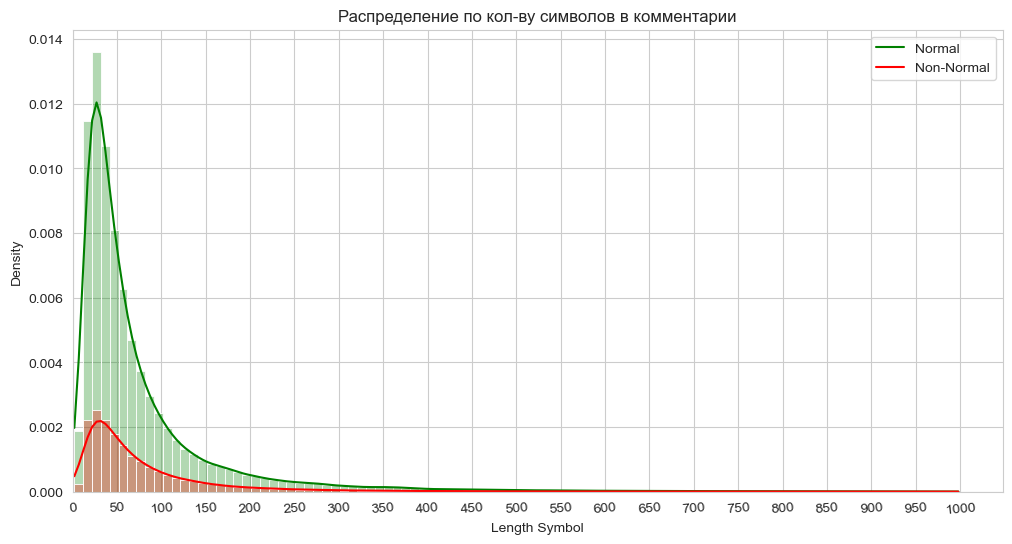

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='length_sym', hue='is_normal',
             bins=100, alpha=0.3, palette={False: 'red', True: 'green'},
             stat='density', kde=True)

plt.xticks(rotation=5)
plt.locator_params(axis='x', nbins=40)
plt.xlabel('Length Symbol')
plt.title('Распределение по кол-ву символов в комментарии')
plt.legend(['Normal', 'Non-Normal'])
plt.xlim(0)
plt.show()

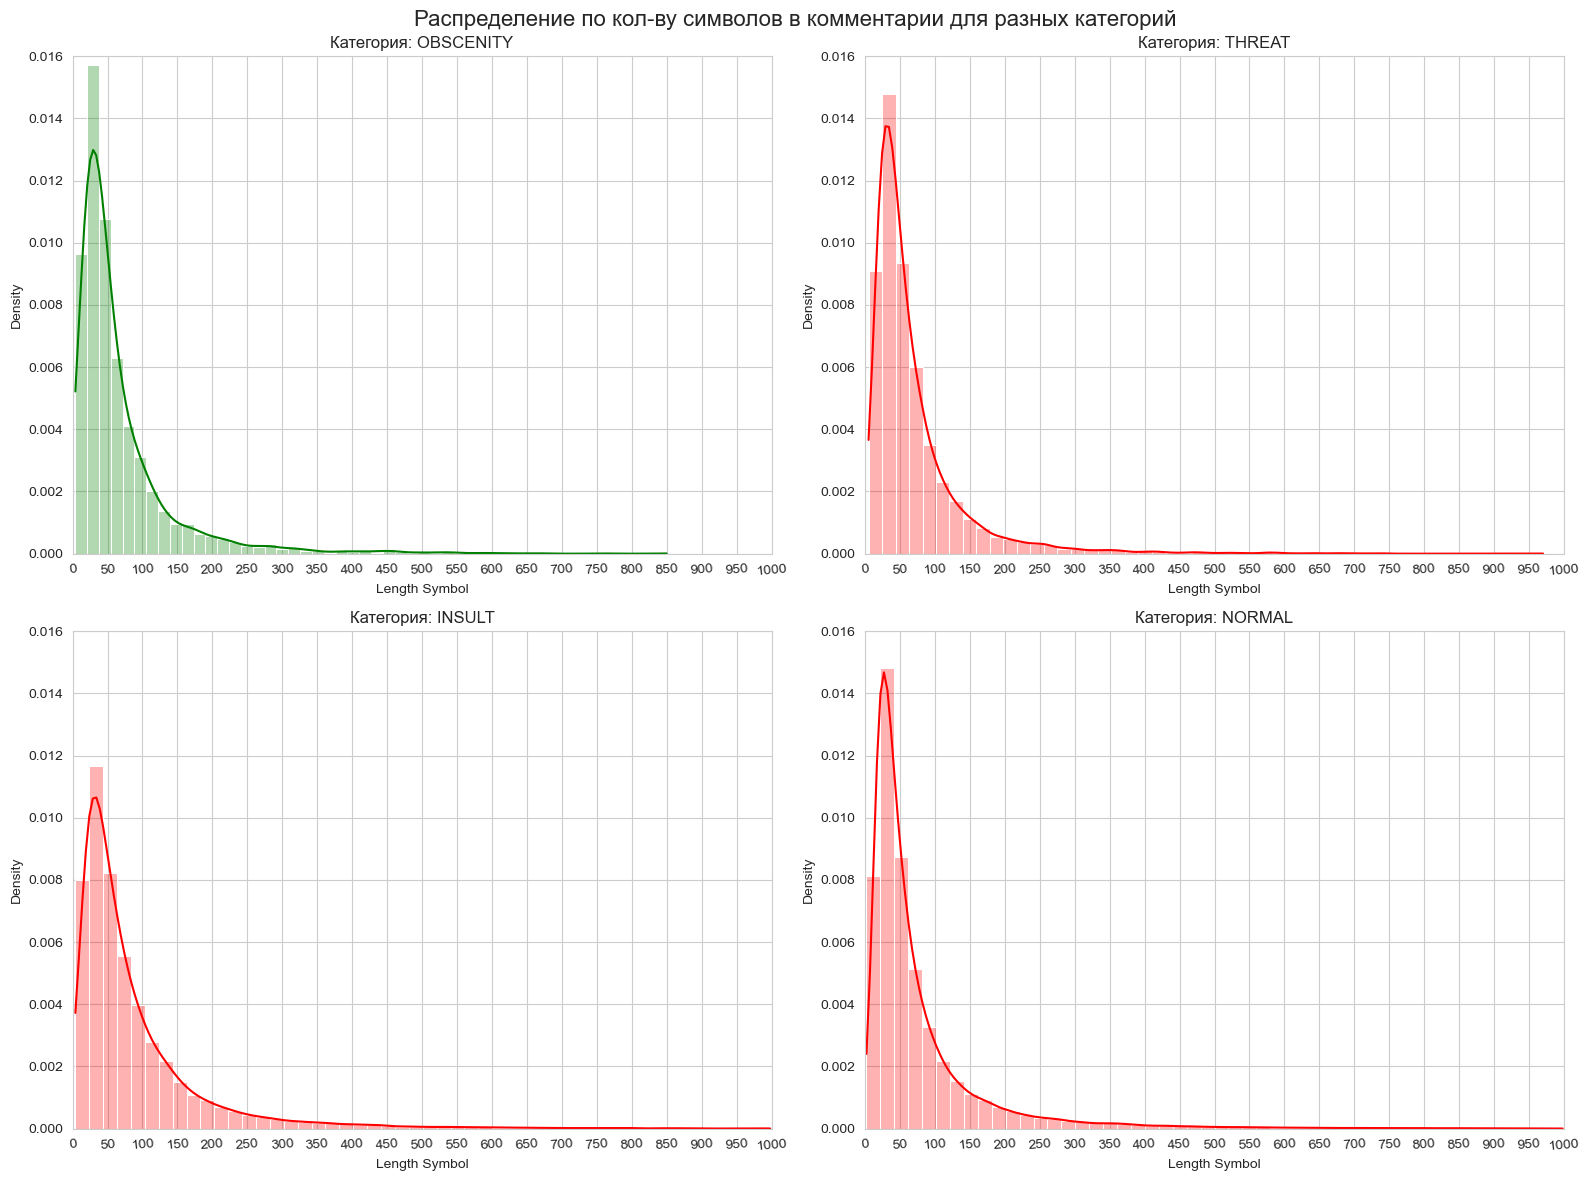

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Распределение по кол-ву символов в комментарии для разных категорий', fontsize=16)

colors = ['green', 'red', 'red', 'red']

for i, category in enumerate(categories):
    row = i // 2
    col = i % 2

    df_filtered = df[df['label'] == category]

    sns.histplot(data=df_filtered, x='length_sym',
                 bins=50, alpha=0.3, color=colors[i],
                 stat='density', kde=True, ax=axes[row, col])

    axes[row, col].set_title(f'Категория: {category}')
    axes[row, col].set_xlabel('Length Symbol')
    axes[row, col].set_ylabel('Density')
    axes[row, col].set_xlim(0, 1000)
    axes[row, col].set_ylim(0, 0.016)
    axes[row, col].set_xticks(range(0, 1001, 50))
    axes[row, col].tick_params(axis='x', rotation=5)
    axes[row, col].locator_params(axis='x', nbins=40)

plt.tight_layout()
plt.show()

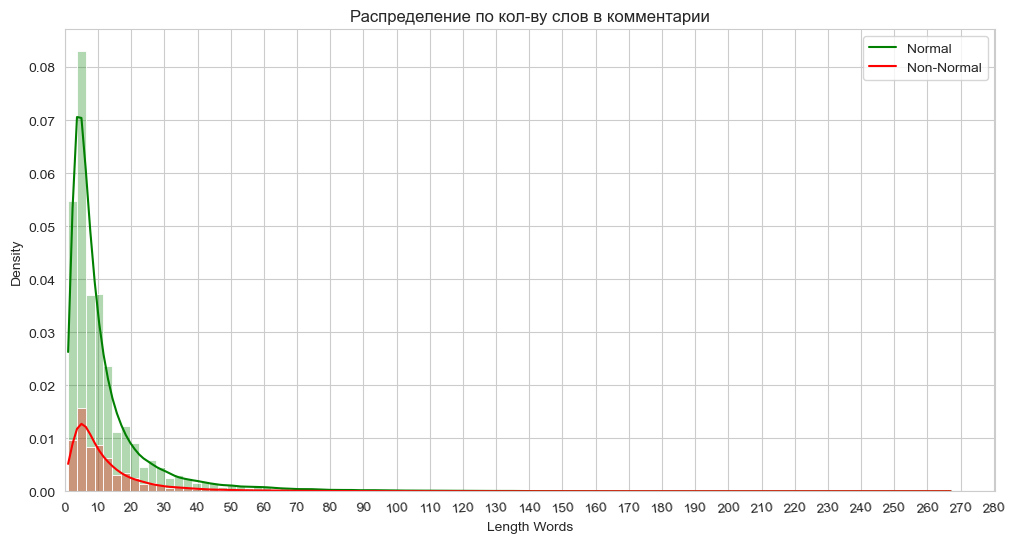

In [28]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='length_words', hue='is_normal',
             bins=100, alpha=0.3, palette={False: 'red', True: 'green'},
             stat='density', kde=True)

plt.xticks(rotation=5)
plt.locator_params(axis='x', nbins=40)
plt.xlabel('Length Words')
plt.title('Распределение по кол-ву слов в комментарии')
plt.legend(['Normal', 'Non-Normal'])
plt.xlim(0)
plt.show()

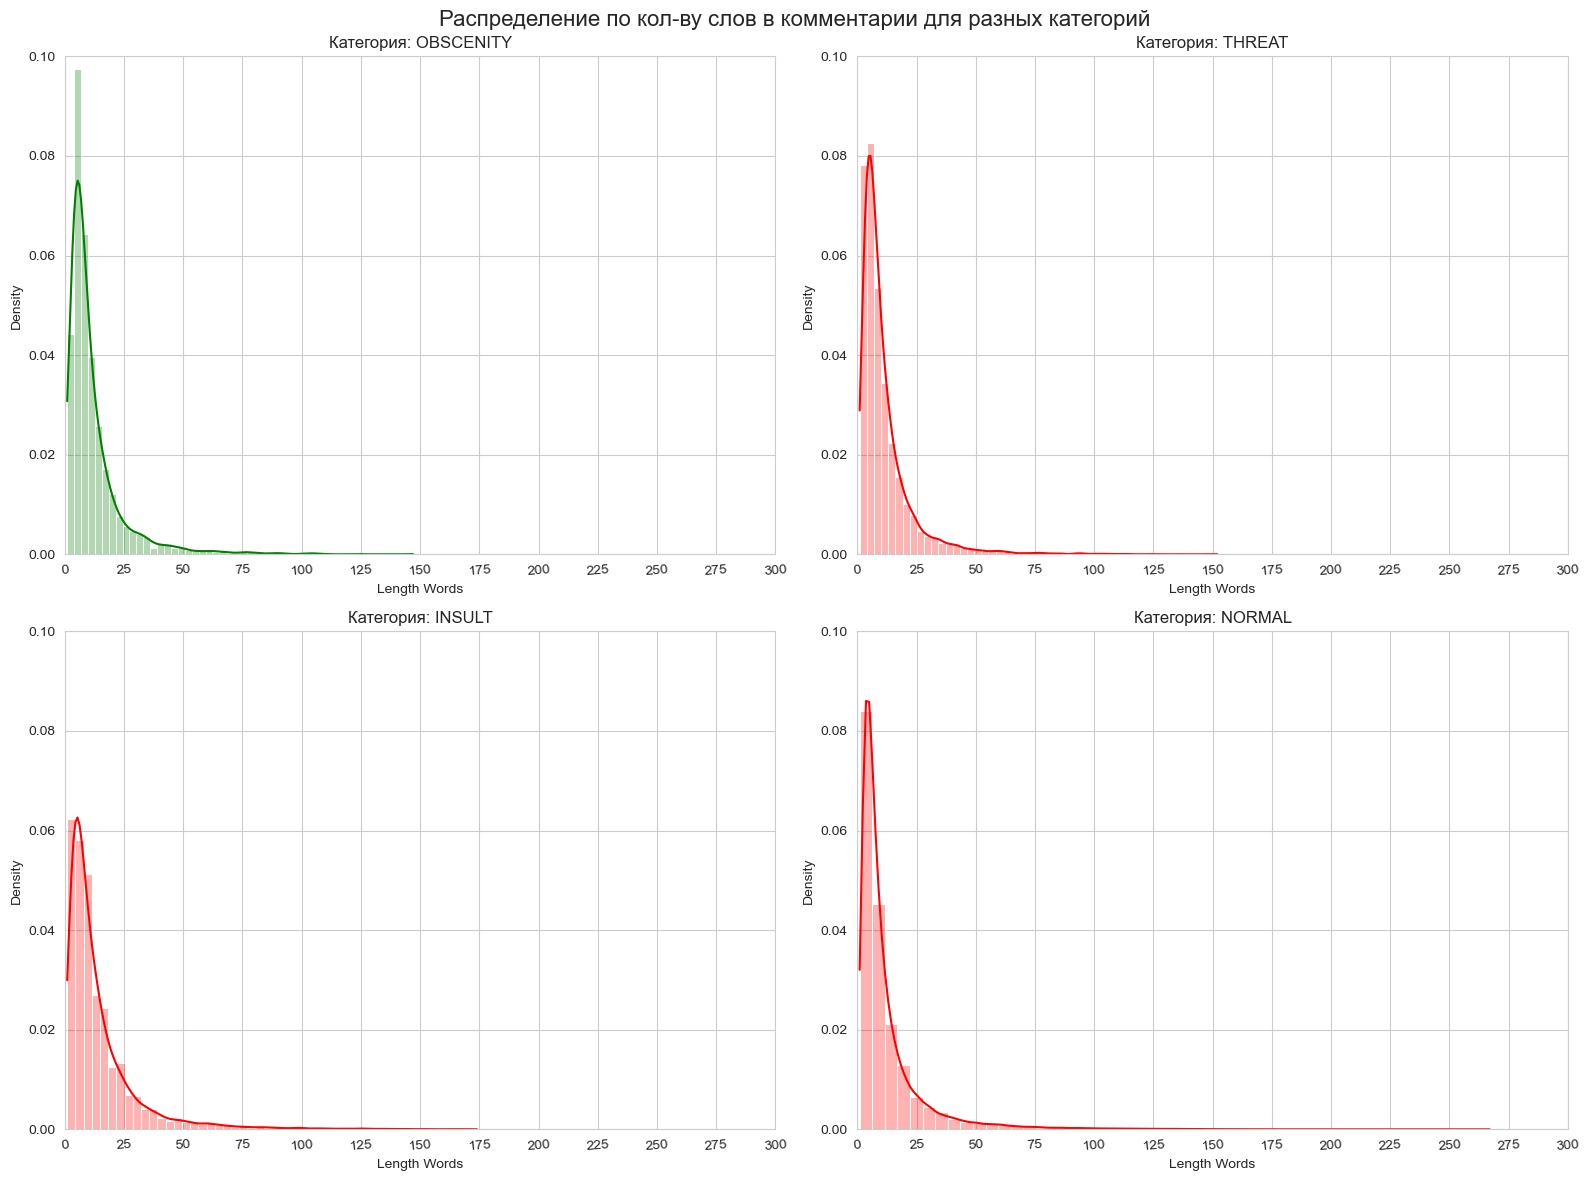

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Распределение по кол-ву слов в комментарии для разных категорий', fontsize=16)

colors = ['green', 'red', 'red', 'red']

for i, category in enumerate(categories):
    row = i // 2
    col = i % 2

    df_filtered = df[df['label'] == category]

    sns.histplot(data=df_filtered, x='length_words',
                 bins=50, alpha=0.3, color=colors[i],
                 stat='density', kde=True, ax=axes[row, col])

    axes[row, col].set_title(f'Категория: {category}')
    axes[row, col].set_xlabel('Length Words')
    axes[row, col].set_ylabel('Density')
    axes[row, col].set_xlim(0, 100)
    axes[row, col].set_ylim(0, 0.1)
    axes[row, col].set_xticks(range(0, 301, 25))
    axes[row, col].tick_params(axis='x', rotation=5)
    axes[row, col].locator_params(axis='x', nbins=40)

plt.tight_layout()
plt.show()

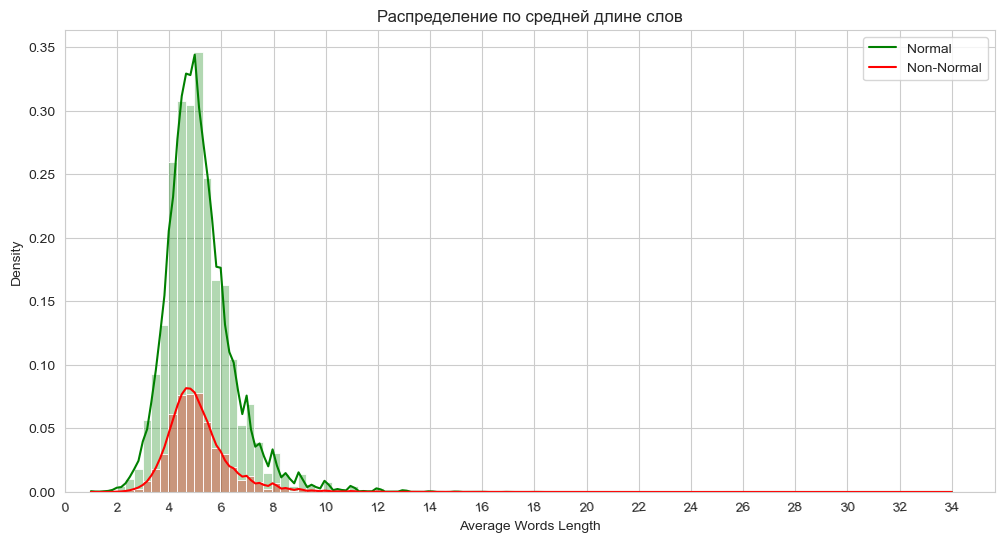

In [30]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='av_word_len', hue='is_normal',
             bins=100, alpha=0.3, palette={False: 'red', True: 'green'},
             stat='density', kde=True)

plt.xticks(rotation=5)
plt.locator_params(axis='x', nbins=30)
plt.xlabel('Average Words Length')
plt.title('Распределение по средней длине слов')
plt.legend(['Normal', 'Non-Normal'])
plt.xlim(0)
plt.show()

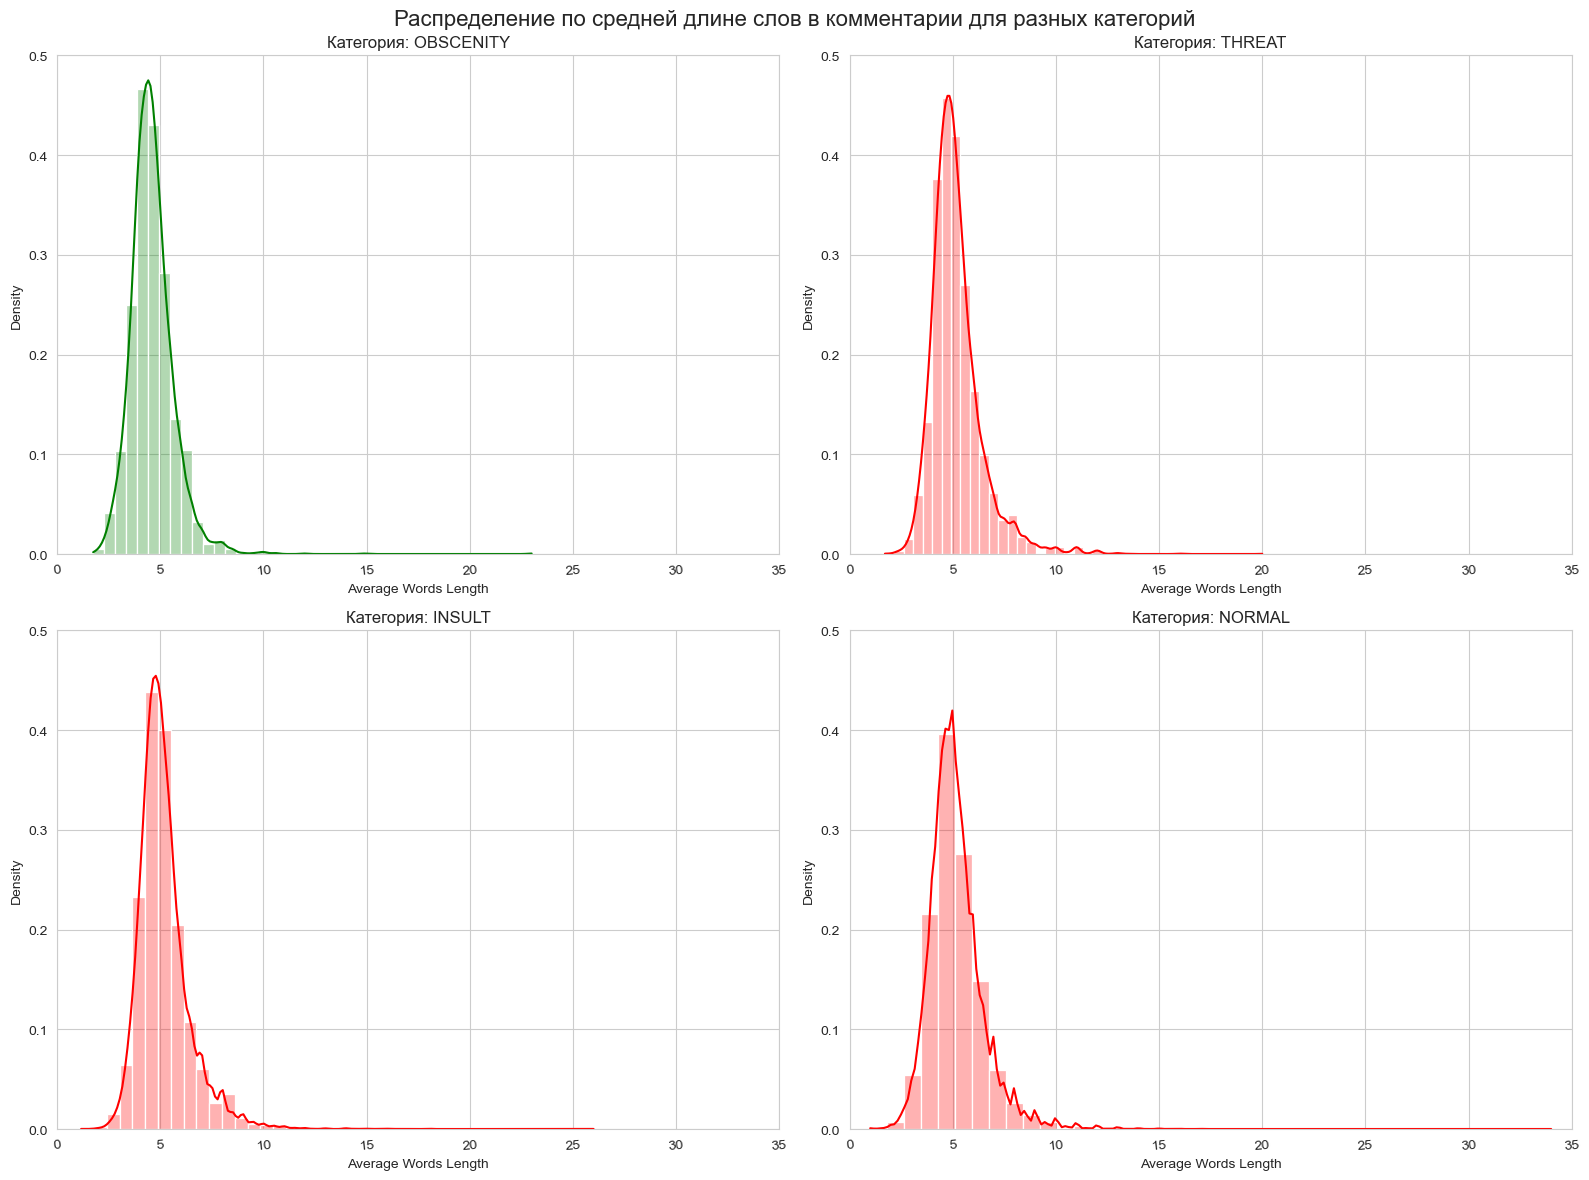

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Распределение по средней длине слов в комментарии для разных категорий', fontsize=16)

colors = ['green', 'red', 'red', 'red']

for i, category in enumerate(categories):
    row = i // 2
    col = i % 2

    df_filtered = df[df['label'] == category]

    sns.histplot(data=df_filtered, x='av_word_len',
                 bins=40, alpha=0.3, color=colors[i],
                 stat='density', kde=True, ax=axes[row, col])

    axes[row, col].set_title(f'Категория: {category}')
    axes[row, col].set_xlabel('Average Words Length')
    axes[row, col].set_ylabel('Density')
    axes[row, col].set_xlim(0, 35)
    axes[row, col].set_ylim(0, 0.5)
    axes[row, col].set_xticks(range(0, 36, 5))
    axes[row, col].tick_params(axis='x', rotation=5)
    axes[row, col].locator_params(axis='x', nbins=40)

plt.tight_layout()
plt.show()

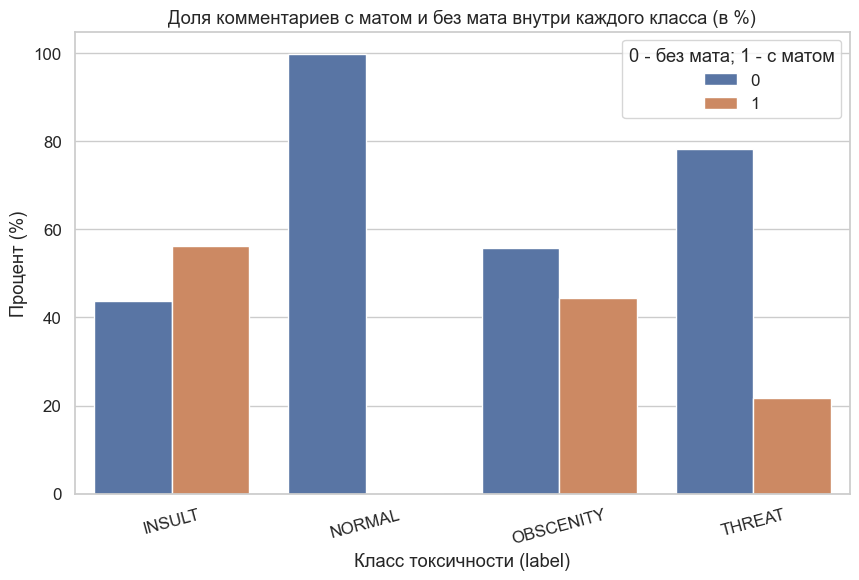

In [32]:
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

plt.figure(figsize=(10,6))
percent_plot = percent_within_label.reset_index().melt(id_vars="label", value_vars=[0,1], var_name="swearing", value_name="percent")
sns.barplot(data=percent_plot, x="label", y="percent", hue="swearing")
plt.title("Доля комментариев с матом и без мата внутри каждого класса (в %)")
plt.ylabel("Процент (%)")
plt.xlabel("Класс токсичности (label)")
plt.legend(title="0 - без мата; 1 - с матом")
plt.xticks(rotation=15)
plt.show()

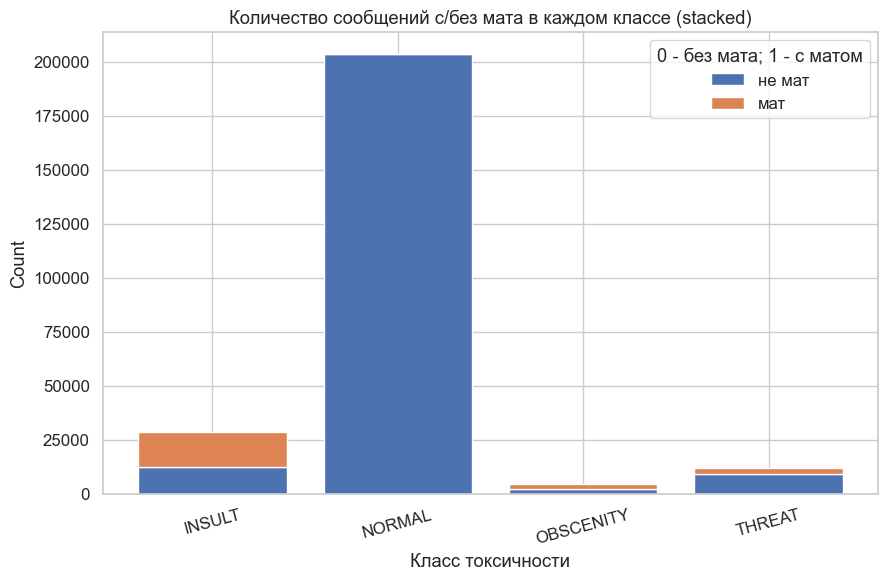

In [33]:
labels = counts.index.tolist()
bar_bottom = np.zeros(len(labels))

fig, ax = plt.subplots(figsize=(10,6))
for col in [0,1]:
    vals = counts[col].values
    ax.bar(labels, vals, bottom=bar_bottom, label=f"{"мат" if col else "не мат"}")
    bar_bottom += vals

ax.set_title("Количество сообщений с/без мата в каждом классе (stacked)")
ax.set_ylabel("Count")
ax.set_xlabel("Класс токсичности")
ax.legend(title="0 - без мата; 1 - с матом")
plt.xticks(rotation=15)
plt.show()

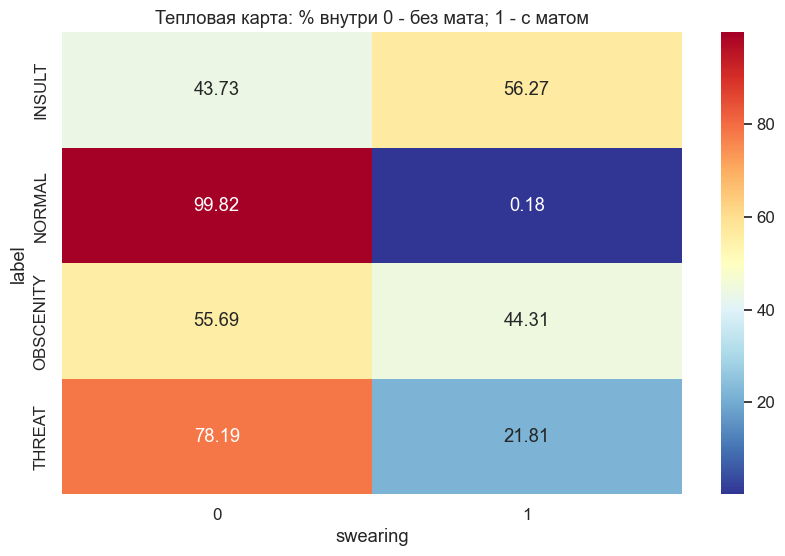

In [34]:
heatmap_data = percent_within_label[[0,1]]
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlBu_r")
plt.title("Тепловая карта: % внутри 0 - без мата; 1 - с матом")
plt.xlabel("swearing")
plt.ylabel("label")
plt.show()


Доля сообщений с матом среди is_normal:


,is_normal,share_with_swearing,share_with_swearing_pct
0,False,0.46,46.03
1,True,0.00,0.18


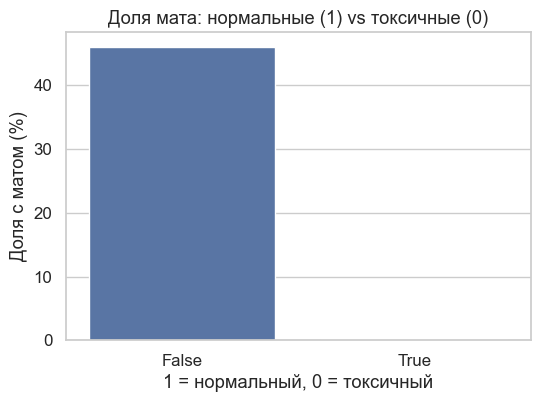

In [35]:
swear_by_normal = df.groupby("is_normal")["swearing"].mean().reset_index().rename(columns={"swearing":"share_with_swearing"})
swear_by_normal["share_with_swearing_pct"] = (swear_by_normal["share_with_swearing"]*100).round(2)
print("\nДоля сообщений с матом среди is_normal:")
display(swear_by_normal)

plt.figure(figsize=(6,4))
sns.barplot(data=swear_by_normal, x="is_normal", y="share_with_swearing_pct")
plt.title("Доля мата: нормальные (1) vs токсичные (0)")
plt.xlabel("1 = нормальный, 0 = токсичный")
plt.ylabel("Доля с матом (%)")
plt.show()


In [36]:
p_toxic_given_swear = 1 - df[df["swearing"]==1]["is_normal"].mean() if df[df["swearing"]==1].shape[0] > 0 else np.nan
p_toxic_given_no_swear = 1 - df[df["swearing"]==0]["is_normal"].mean() if df[df["swearing"]==0].shape[0] > 0 else np.nan
print(f"\nP(toxic | swearing=1) = {p_toxic_given_swear:.3f}")
print(f"P(toxic | swearing=0) = {p_toxic_given_no_swear:.3f}")

total = len(df)
total_swear = df["swearing"].sum()
print(f"\nВсего сообщений: {total}, из них с матом: {total_swear} ({total_swear/total*100:.2f}%)")

print("\nПримеры (по одному) для каждой комбинации label+swearing:")
examples = df.groupby(["label","swearing"]).apply(lambda g: g.head(1)).reset_index(drop=True)
display(examples[["label","swearing"] + [c for c in df.columns if c not in ['label','swearing']][:3]])  # показываем первые 3 другие колонки


P(toxic | swearing=1) = 0.983
P(toxic | swearing=0) = 0.106

Всего сообщений: 248281, из них с матом: 20895 (8.42%)

Примеры (по одному) для каждой комбинации label+swearing:


,label,swearing,comment,cleaned_comment,comment_without_punct
0,INSULT,False,скотина! что сказать,скотина сказать,скотина что сказать
1,INSULT,True,долбоебы это фэйк,долбоебы это фэйк,долбоебы это фэйк
2,NORMAL,False,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,я сегодня проезжала по рабочей и между домами ...
3,NORMAL,True,причём здесь путин. путин и каспаров - одного ...,причём путин путин каспаров одного поля твари ...,причём здесь путин путин и каспаров - одного п...
4,OBSCENITY,False,эти генеральши знают где соснуть и раздвинуть ...,генеральши знают соснуть раздвинуть зад передо...,эти генеральши знают где соснуть и раздвинуть ...
5,OBSCENITY,True,"хрен в жопу этому мудаку , а не респект",хрен жопу этому мудаку респект,хрен в жопу этому мудаку а не респект
6,THREAT,False,заколоть этого плешивого урода что бы крякнул ...,заколоть плешивого урода крякнул селезень ганд...,заколоть этого плешивого урода что бы крякнул ...
7,THREAT,True,убить такого мало мразь сука отрубить голову б...,убить такого мало мразь сука отрубить голову б...,убить такого мало мразь сука отрубить голову б...



=== Анализ признака: has_positive_emoji ===

Количество комментариев (label × feature):


has_positive_emoji,0,1
label,,
INSULT,27548,1018
NORMAL,188940,14737
OBSCENITY,3996,265
THREAT,11464,313



Проценты внутри класса (label):


has_positive_emoji,0,1
label,,
INSULT,96.44,3.56
NORMAL,92.76,7.24
OBSCENITY,93.78,6.22
THREAT,97.34,2.66


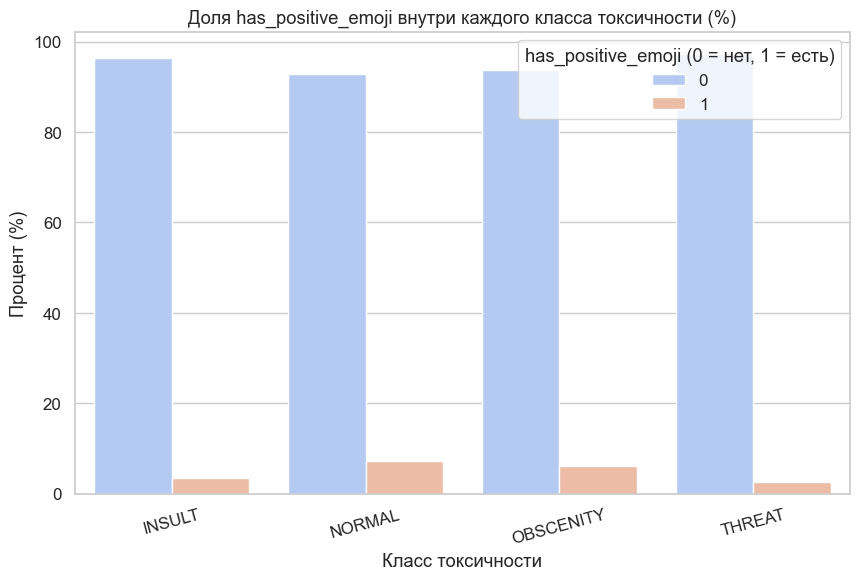

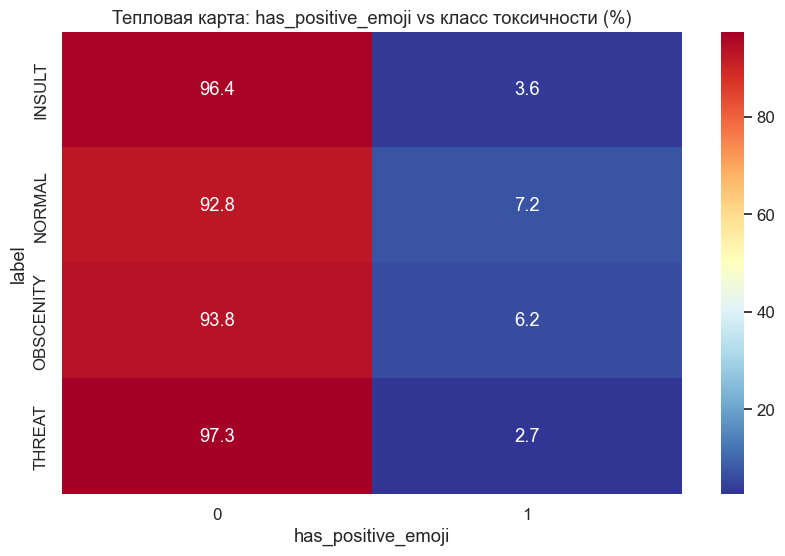


Доля комментариев, где has_positive_emoji среди нормальных/токсичных:


,is_normal,share_with_feature,share_with_feature_pct
0,False,0.04,3.58
1,True,0.07,7.24


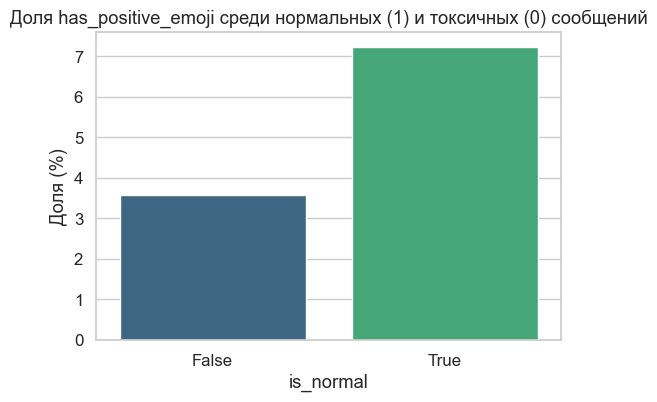

P(toxic | has_positive_emoji=1) = 0.098
P(toxic | has_positive_emoji=0) = 0.185

=== Анализ признака: has_negative_emoji ===

Количество комментариев (label × feature):


has_negative_emoji,0,1
label,,
INSULT,28089,477
NORMAL,203120,557
OBSCENITY,4232,29
THREAT,11544,233



Проценты внутри класса (label):


has_negative_emoji,0,1
label,,
INSULT,98.33,1.67
NORMAL,99.73,0.27
OBSCENITY,99.32,0.68
THREAT,98.02,1.98


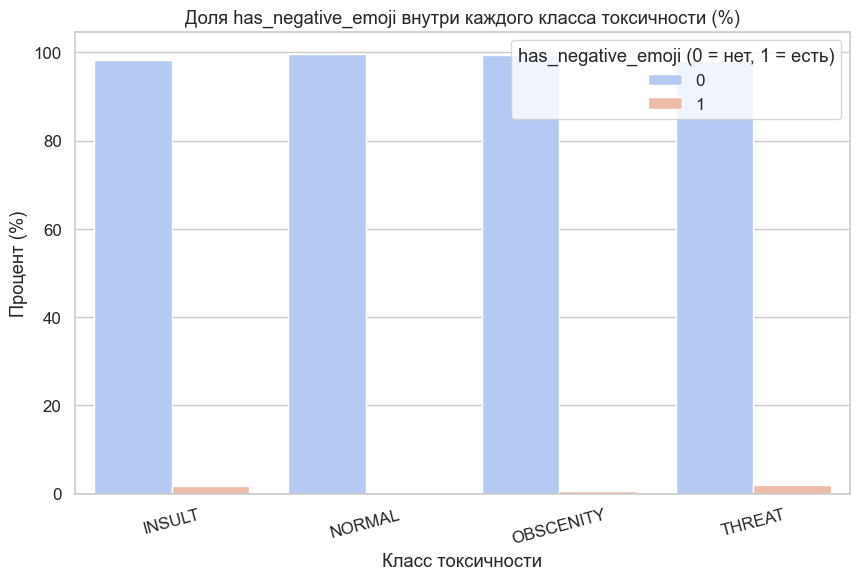

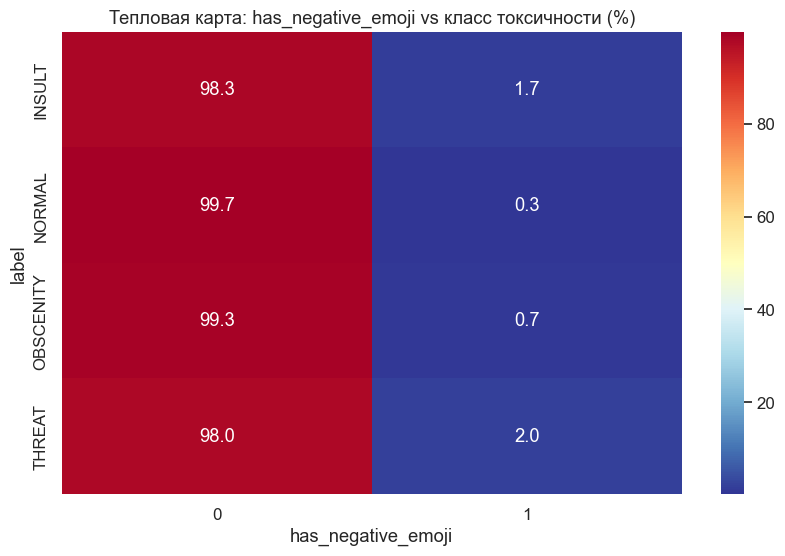


Доля комментариев, где has_negative_emoji среди нормальных/токсичных:


,is_normal,share_with_feature,share_with_feature_pct
0,False,0.02,1.66
1,True,0.00,0.27


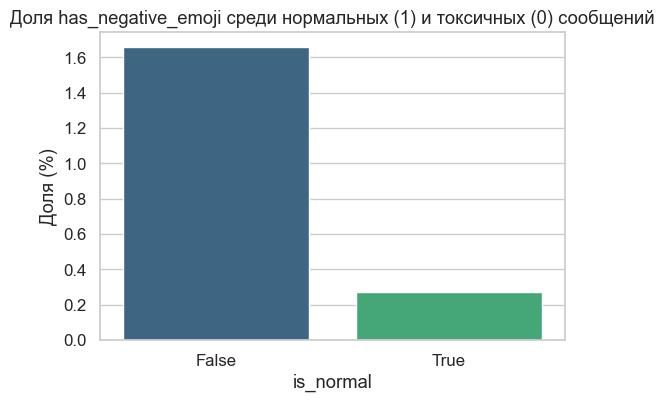

P(toxic | has_negative_emoji=1) = 0.570
P(toxic | has_negative_emoji=0) = 0.178

=== Анализ признака: has_obscene_emoji ===

Количество комментариев (label × feature):


has_obscene_emoji,0,1
label,,
INSULT,28561,5
NORMAL,203654,23
OBSCENITY,4253,8
THREAT,11777,0



Проценты внутри класса (label):


has_obscene_emoji,0,1
label,,
INSULT,99.98,0.02
NORMAL,99.99,0.01
OBSCENITY,99.81,0.19
THREAT,100.00,0.00


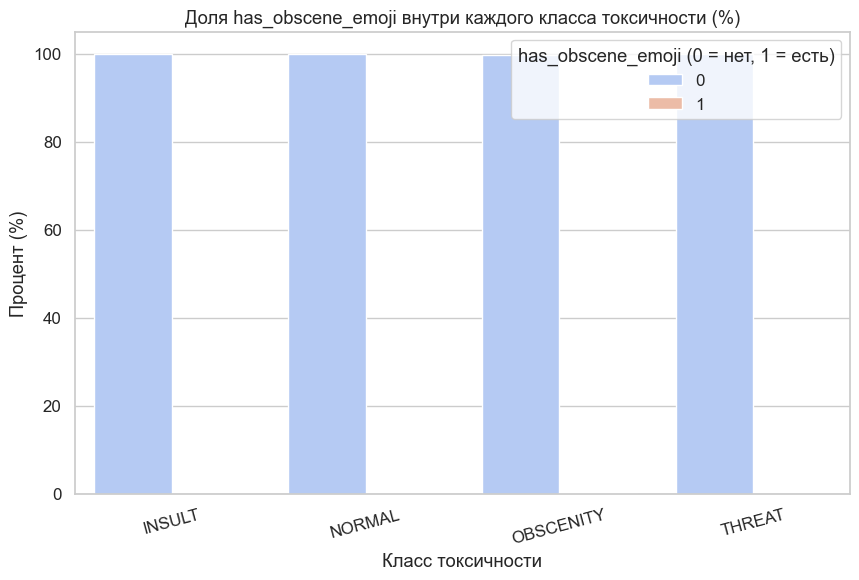

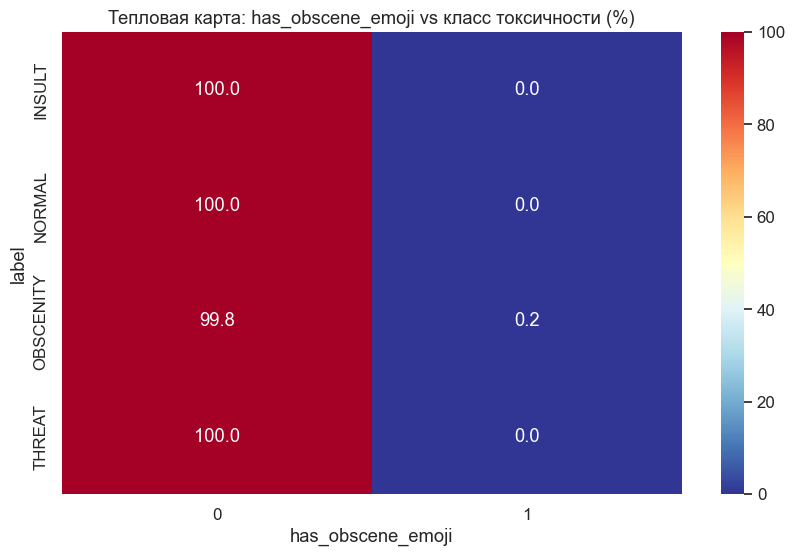


Доля комментариев, где has_obscene_emoji среди нормальных/токсичных:


,is_normal,share_with_feature,share_with_feature_pct
0,False,0.00,0.03
1,True,0.00,0.01


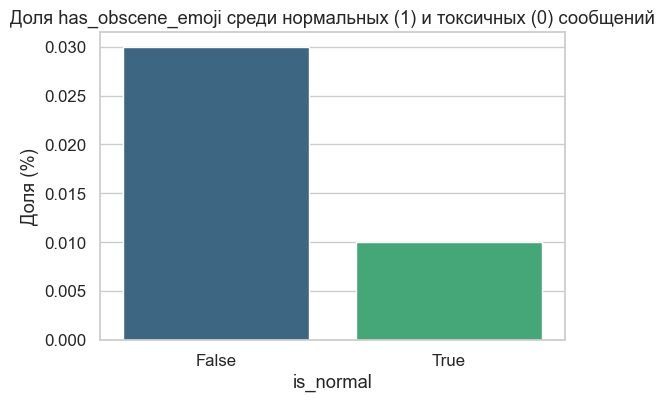

P(toxic | has_obscene_emoji=1) = 0.361
P(toxic | has_obscene_emoji=0) = 0.180


In [37]:
binary_features = ["has_positive_emoji", "has_negative_emoji", "has_obscene_emoji"]


def analyze_feature(df, feature, label_col="label"):
    print(f"\n=== Анализ признака: {feature} ===")
    
    counts = df.groupby([label_col, feature]).size().unstack(fill_value=0)
    counts.columns = counts.columns.astype(int)
    
    percent_within_label = (counts.div(counts.sum(axis=1), axis=0) * 100).round(2)
    
    percent_within_feature = (counts.T.div(counts.sum(axis=1), axis=0) * 100).round(2)
    
    print("\nКоличество комментариев (label × feature):")
    display(counts)
    
    print("\nПроценты внутри класса (label):")
    display(percent_within_label)
    
    percent_plot = percent_within_label.reset_index().melt(id_vars=label_col, var_name=feature, value_name="percent")
    plt.figure(figsize=(10,6))
    sns.barplot(data=percent_plot, x=label_col, y="percent", hue=feature, palette="coolwarm")
    plt.title(f"Доля {feature} внутри каждого класса токсичности (%)")
    plt.xlabel("Класс токсичности")
    plt.ylabel("Процент (%)")
    plt.legend(title=f"{feature} (0 = нет, 1 = есть)")
    plt.xticks(rotation=15)
    plt.show()
    
    sns.heatmap(percent_within_label, annot=True, fmt=".1f", cmap="RdYlBu_r")
    plt.title(f"Тепловая карта: {feature} vs класс токсичности (%)")
    plt.xlabel(feature)
    plt.ylabel("label")
    plt.show()
    
    normal_stat = (
        df.groupby("is_normal")[feature]
        .mean()
        .reset_index()
        .rename(columns={feature: "share_with_feature"})
    )
    normal_stat["share_with_feature_pct"] = (normal_stat["share_with_feature"]*100).round(2)
    print("\nДоля комментариев, где", feature, "среди нормальных/токсичных:")
    display(normal_stat)
    
    plt.figure(figsize=(6,4))
    sns.barplot(data=normal_stat, x="is_normal", y="share_with_feature_pct", palette="viridis")
    plt.title(f"Доля {feature} среди нормальных (1) и токсичных (0) сообщений")
    plt.xlabel("is_normal")
    plt.ylabel("Доля (%)")
    plt.show()

    p_toxic_given_feat = 1 - df[df[feature]==1]["is_normal"].mean() if df[df[feature]==1].shape[0] > 0 else np.nan
    p_toxic_given_no_feat = 1 - df[df[feature]==0]["is_normal"].mean() if df[df[feature]==0].shape[0] > 0 else np.nan
    print(f"P(toxic | {feature}=1) = {p_toxic_given_feat:.3f}")
    print(f"P(toxic | {feature}=0) = {p_toxic_given_no_feat:.3f}")
    
for feat in binary_features:
    analyze_feature(df, feat)

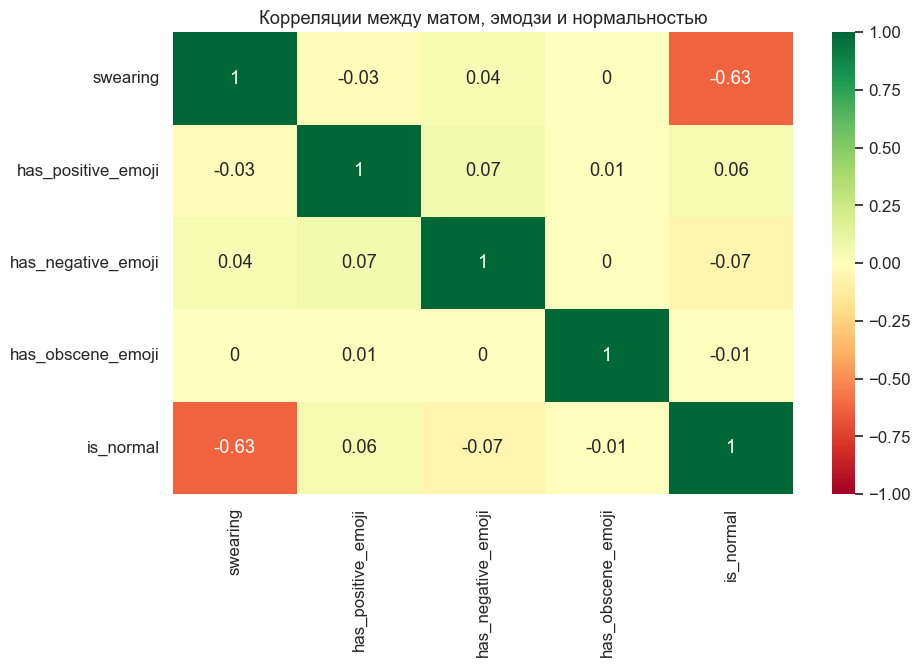

In [38]:
corr_matrix = df[["swearing"] + binary_features + ["is_normal"]].corr().round(2)
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", vmin=-1, vmax=1)
plt.title("Корреляции между матом, эмодзи и нормальностью")
plt.show()

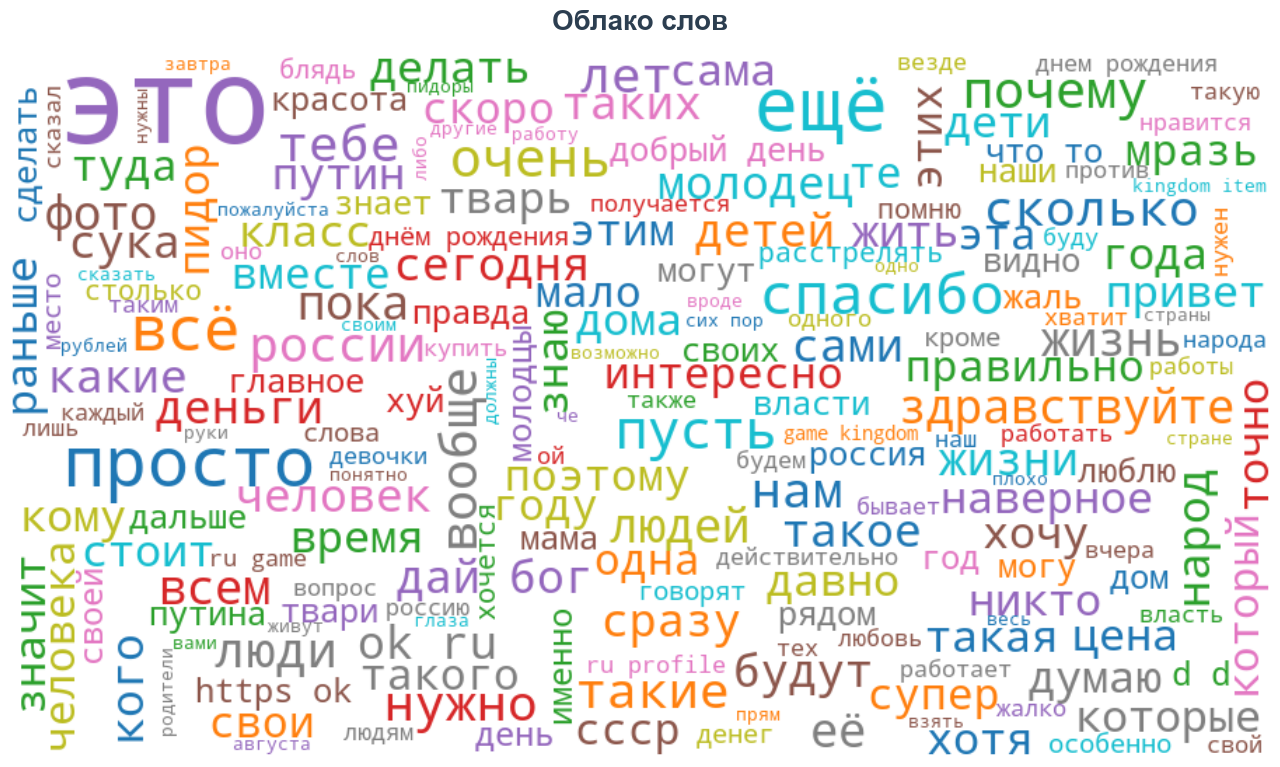

In [39]:
plt.figure(figsize=(13, 8))
word_cloud = WordCloud(
    background_color='#ffffff',
    max_font_size=85,
    width=900,
    height=500,
    colormap='tab10',
    contour_width=3,
    contour_color='#34495e',
    margin=2
).generate(" ".join(df['cleaned_comment']))

plt.imshow(word_cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов',
          fontsize=20,
          fontweight='semibold',
          color='#2c3e50',
          pad=20)
plt.tight_layout()
plt.show()

### Выводы:

Графики визуально отличаются незначительно, но все же можно выделить несколько моментов:
- Комментарии с оскорблениями (INSULT) реже имеют комментарии с кол-вом символов меньше 50 по сравнению с другими категориями. Комментарии с описанием или угрозой сексуального насилия (OBSCENITY), наоборот, чаще ограничиваются 50ю символами
- Распределение по кол-ву слов сильно похоже на распределению по кол-ву символов и имеют высокую пололжительную корреляцию (может в будущем создать проблему мультиколлинеарности)
- Токсичные комментарии визуально практически не имеют отличий по распределению по средней длине слов между различными классами токсичности, но чаще имеют среднюю длину до 5 по сравнению с нормальными
- При наличии мата в комментарии можно с очень большой точностью определить, что он является токсичным, однако всего < 10% комментариев содержат мат, и существует 24073 записи, где нет мата, но при они токсичны - отловить их будет труднее всего.
- Относительно эмодзи можно сказать, что довольно мало комментариев в датасете содержат их, поэтому их вклад в работу модели вряд ли будет существенным, однако в теории может позволить сделать более точный прогноз в редких случаях.
- Судя по облаку слов, частыми темами обсуждений в комментариях являются: политика (россия, народ, власть, путин, ссср), финансы (деньги, цена, работать, купить), поздравления с днем рождения (днем рождения, днём рождения)

# Морфологический анализ комментариев

Добавим в датасет новые признаки, относящиеся к морфологическим характеристикам отдельных слов в комментарии, а именно:
1. `vocative` -- бинарный признак наличия в тексте комментария _вокатива_, существительного в звательном падеже, используемого для обращения. (Пример: "господи!", "боже", "молодцы", "уроды"). При этом исключим из числа вокативов имена собственные.
2. `imperative`  -- бинарный признак наличия глагола в повелительном наклонении.
3. `expr_punkt` -- бинарный признак присутствия идущих подряд вопросительных, восклицательных знаков или точек.
4. `2nd_prsn_count` -- количество личных и притяжательных местоимений 2 лица
5. `3nd_prsn_count` -- количество личных и притяжательных местоимений 3 лица
6. `adj_count` -- количество прилагательных

**Цель:** проверить есть ли отличия по данным признакам между токсичными и нормальными комментариями

## Добавление новых признкав

In [40]:
analyzer = pymorphy3.MorphAnalyzer()

SECOND_PERSON_PRONOUN = {
    'ты', 'тебя', 'тебе', 'тобой', 'вами', 'вас', 'вам', 'вами', 'вы',
    'твой', 'твоя', 'твоё', 'твои', 'твоих', 'твоему', 'твоим', 'твоими',
    'ваш', 'ваша', 'ваше', 'ваши', 'ваших', 'вашему', 'вашим', 'вашими',
    'сам', 'сама', 'вашей', 'свой', 'своя', 'свои'
}

THIRD_PERSON_PRONOUN = {
    'он', 'она', 'оно', 'они', 'его', 'её', 'их', 'ему', 'ей', 'ими', 'них',
    'этот', 'эта', 'это', 'эти', 'этим', 'эту', 'этих', 'того', 'та', 'те',
    'тот', 'тем', 'ту', 'тех', 'тех', 'теми', 'тому', 'таким', 'такая', 'такой'
}

GREETINGS = {
    'добрый', 'утро', 'день', 'вечер', 'привет', 'здравствуйте', 'я', 'мы'
}

PROPER_NAME_TAGS = {
    'Name', 'Surn', 'Patr', 'Geox', 'Orgn', 'Trad'
}

PRECOMMA_PATTERN = re.compile(r"^\s*[а-яё.\s]+[,!]")
PUNCTUATION_PATTERN = re.compile(r"[?!\.]{2,}")


# Проверка является ли слово прилагательным
def is_adjective(parsed_word):
    pos = parsed_word.tag.POS
    return pos == "ADJF"


# Проверка является ли слово одушевленным существительным в именительном падеже или местоимением
def is_anim_noun(parsed_word):
    pos = parsed_word.tag.POS
    is_nomn = "nomn" in parsed_word.tag
    is_anim = "anim" in parsed_word.tag
    return (pos == "NOUN" and is_nomn and is_anim) or pos == "NPRO"


# Проверка наклонения глагола (изъявительное/указательное)
def is_imperative(word):
    mood = analyzer.parse(word)[0].tag.mood
    return mood == "impr"


# Проверка на признак собственного имени
def is_proper_name(parsed_word):
    return any(tag_name in parsed_word.tag for tag_name in PROPER_NAME_TAGS)


# Проверка на наличие вокатива
def is_vocative(comment):
    pre_comma_part_raw = PRECOMMA_PATTERN.search(comment)  # ищем слова в начале текста, отделенные знаком препинания
    if not pre_comma_part_raw:
        return False
    if len(comment_without_punct(comment[pre_comma_part_raw.end():]).split()) == 0:
        return False
    cleaned_words = comment_without_punct(pre_comma_part_raw.group()).split()
    if len(cleaned_words) > 2:
        return False
    parsed_words = list(map(lambda word: analyzer.parse(word)[0], cleaned_words))

    return all(map(lambda pword: (is_anim_noun(pword) or is_adjective(pword)) and not is_proper_name(pword) and pword.word not in GREETINGS, parsed_words))


# Проверка на наличие нескольких идущих подряд знаков препинания
def expressive_punctuation(comment):
    return len(PUNCTUATION_PATTERN.findall(comment)) > 0

def extract_word_morph_data(word):
    parse_result = analyzer.parse(word)[0]  # берем первое слово из списка похожих слов, отсортированных по убыванию похожести
    normalized = parse_result.normalized.word
    mood = parse_result.tag.mood
    second_person_pronoun = word in SECOND_PERSON_PRONOUN
    third_person_pronoun = word in THIRD_PERSON_PRONOUN
    is_adj = is_adjective(parse_result)
    return pd.Series(
        [word, normalized, mood, second_person_pronoun, third_person_pronoun, is_adj],
        index=["word", "normalized", "mood", "is_2nd_pronoun", "is_3rd_pronoun", "is_adj"]
    )


def extract_morph_data(cleaned_comment):
    morph_data = pd.concat(map(extract_word_morph_data, cleaned_comment.split()), axis=1).transpose()
    imperative = morph_data[morph_data["mood"] == "impr"]["word"].count() > 0
    person_2nd_count = morph_data[morph_data["is_2nd_pronoun"]]["word"].count()
    person_3nd_count = morph_data[morph_data["is_3rd_pronoun"]]["word"].count()
    adjectives = morph_data[morph_data["is_adj"].to_numpy()]["word"].count()
    return pd.Series(
        [imperative, person_2nd_count, person_3nd_count, adjectives],
        index=["imperative", "2nd_prsn_count", "3nd_prsn_count", "adj_count"]
    )

In [41]:
# Вычисление новых признаков и запись нового датасета в отдельный файл
morth_features = df['comment_without_punct'].apply(extract_morph_data)
df = pd.concat([df, morth_features], axis=1)
df['vocative'] = df['comment'].apply(is_vocative)
df['expr_punct'] = df['comment'].apply(expressive_punctuation)
df.to_csv("./../data/toxic_comments_with_morph.csv", index=True)

In [42]:
# Проверим, что в новых признаках нет пропусков
new_features = ['comment', '2nd_prsn_count', '3nd_prsn_count', 'adj_count', 'imperative', 'vocative', 'expr_punct']
df[new_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248281 entries, 0 to 248280
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   comment         248281 non-null  object
 1   2nd_prsn_count  248281 non-null  int64 
 2   3nd_prsn_count  248281 non-null  int64 
 3   adj_count       248281 non-null  int64 
 4   imperative      248281 non-null  bool  
 5   vocative        248281 non-null  bool  
 6   expr_punct      248281 non-null  bool  
dtypes: bool(3), int64(3), object(1)
memory usage: 8.3+ MB


## Анализ категориальных признаков

Для категориальных признаков построим таблицу сопряженности с целевым признаком `label`, а затем с помощью $\chi^2$-критерия проанализируем наличие статистической зависимости между признаками.

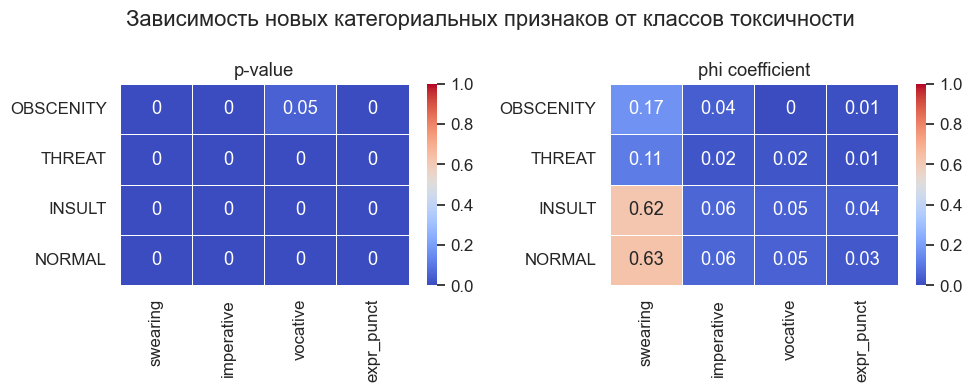

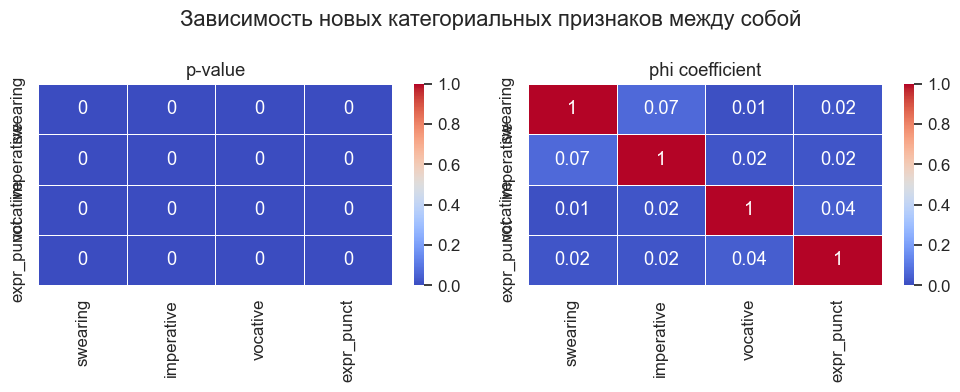

In [43]:
cat_features = ['swearing', 'imperative', 'vocative', 'expr_punct']

def calc_chi2_contingency(first_feature, second_feature):
    tab = pd.crosstab(first_feature, second_feature)
    chi2, p, dof, expected = chi2_contingency(tab)
    phi = np.sqrt(chi2 / tab.to_numpy().sum())

    return np.round(np.float64(p), 2), np.round(np.float64(phi), 2)

def show_heatmaps(cat_features: pd.DataFrame, other_features: pd.DataFrame, title=None):
    n = other_features.shape[1]
    m = cat_features.shape[1]
    p_values = [[(0, 0)] * m for _ in range(n)]
    phi_values = [[(0, 0)] * m for _ in range(n)]
    for i in range(n):
        for j in range(m):
            p, phi = calc_chi2_contingency(cat_features.iloc[:, j], other_features.iloc[:, i])
            p_values[i][j] = p
            phi_values[i][j] = phi

    index = other_features.columns
    columns = cat_features.columns
    p_df = pd.DataFrame(p_values, index=index, columns=columns)
    phi_df = pd.DataFrame(phi_values, index=index, columns=columns)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, n))
    sns.heatmap(p_df, annot=True, ax=ax1, cmap='coolwarm', linewidths=0.5, vmin=0, vmax=1)
    ax1.set_title("p-value")
    sns.heatmap(phi_df, annot=True, ax=ax2, cmap='coolwarm', linewidths=0.5, vmin=0, vmax=1)
    ax2.set_title("phi coefficient")
    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

categories_df = pd.concat([(df['label'] == category).rename(category) for category in categories], axis=1)
show_heatmaps(df[cat_features], categories_df, "Зависимость новых категориальных признаков от классов токсичности")
show_heatmaps(df[cat_features], df[cat_features], "Зависимость новых категориальных признаков между собой")


**Выводы**:
* Для всех пар признак/класс токсичности кроме vocative/OBSCENITY наблюдается статистически значимая зависимость. Но на величину $\chi2$ влияет также размер выборки, а так как в нашем случае он большой, зависимость стоит оценивать по коэффициенту $\phi= \sqrt{\frac{\chi^2}{N}}$. Коэффициент $\phi$ силы зависимости для всех пар < 0.1, следовательно зависимость если и есть, то очень слабая.
* Для пар признак/признак картина аналогичная: статистически значимая зависимость есть, но очень слабая.
* Признак наличия мата `swearing` тут включен для сравнения: для него $\phi$ = 0.62, следовательно наблюдается статистически значимая сильная зависимость между токсичностью комментария и наличием мата (что не удивительно), то есть `swearing` может хорошо предсказывать классы NORMAL/INSULT. С другой стороны, зависимость от двух дргугих классов THREAT/OBSCENITY достаточно слабая.


## Облака вокативов

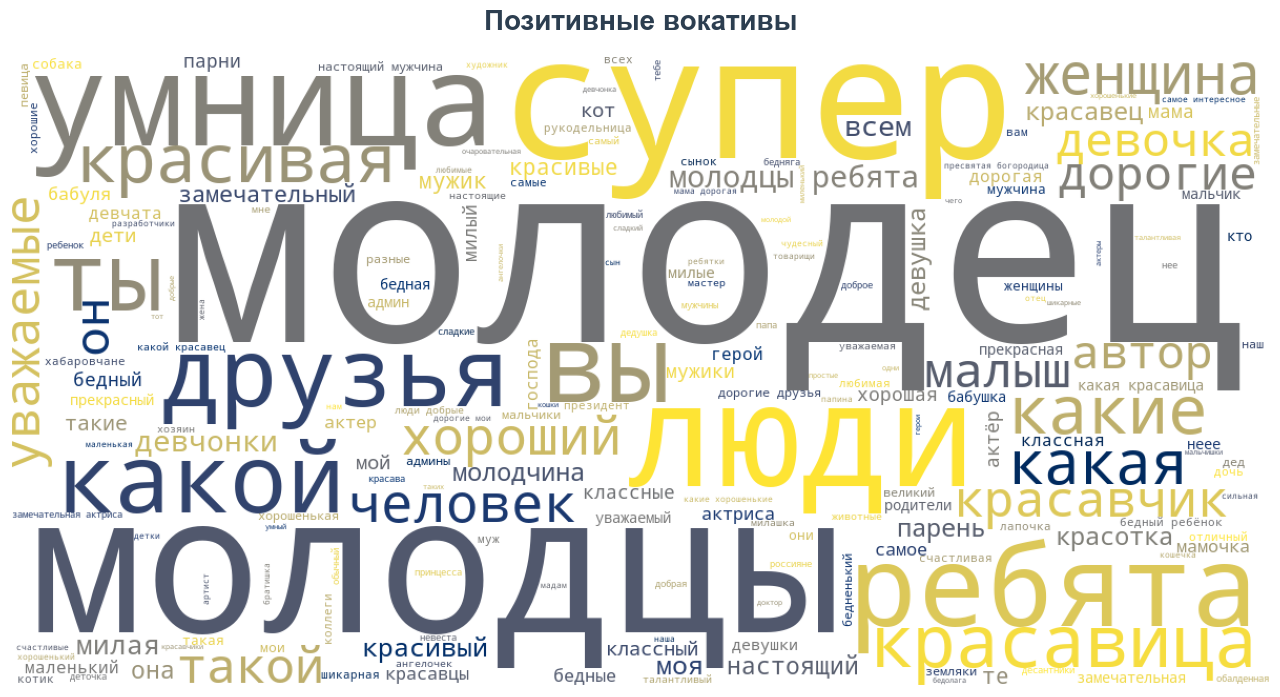

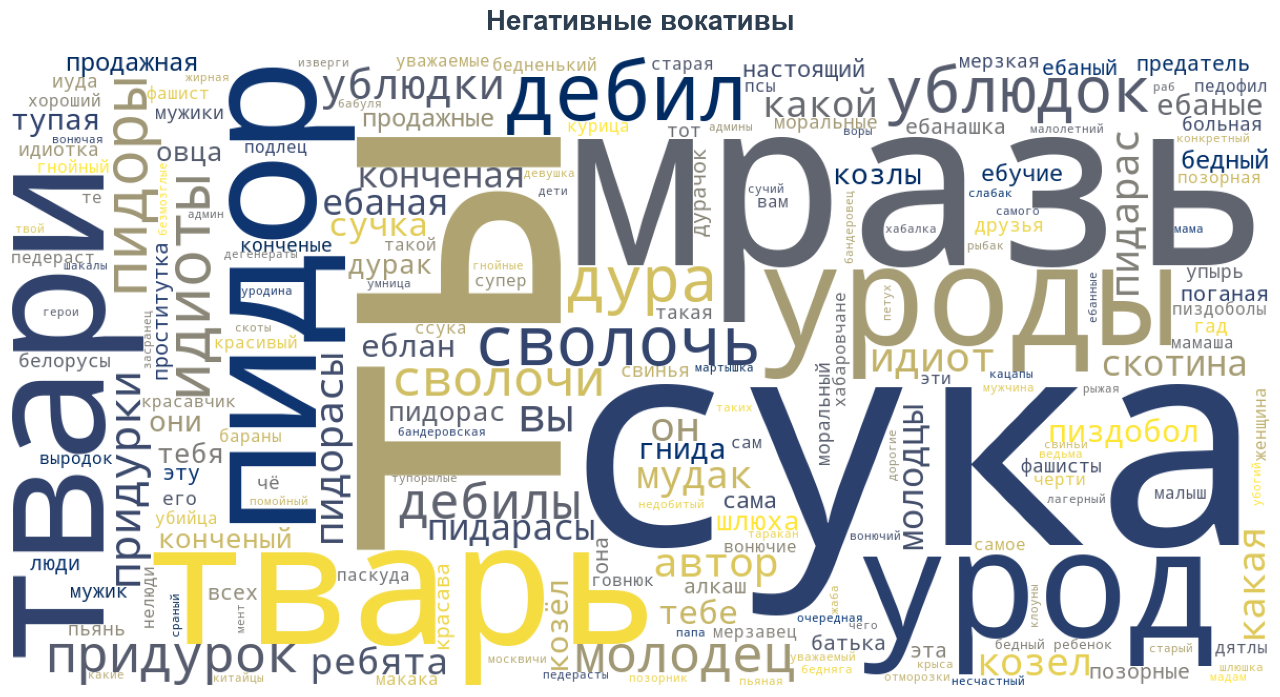

In [44]:
def extract_vocative(comment):
    return PRECOMMA_PATTERN.search(comment).group()

def show_wordcloud(data, title):
    plt.figure(figsize=(13, 8))
    word_cloud = WordCloud(
        background_color='white',
        colormap="cividis",
        min_font_size=2,
        width=1200, height=600,
        contour_width=10,
        margin=2
    ).generate(" ".join(data))

    plt.imshow(word_cloud)
    plt.axis('off')
    plt.title(title,
              fontsize=20,
              fontweight='semibold',
              color='#2c3e50',
              pad=20)
    plt.tight_layout()
    plt.show()

pos_vocatives = df[((df['vocative']) & (df['is_normal']))]['comment'].apply(extract_vocative)
neg_vocatives = df[((df['vocative']) & (~df['is_normal']))]['comment'].apply(extract_vocative)
show_wordcloud(pos_vocatives, 'Позитивные вокативы')
show_wordcloud(neg_vocatives, 'Негативные вокативы')

## Анализ численных признаков

In [45]:
new_features = ['2nd_prsn_count', '3nd_prsn_count', 'adj_count']

In [46]:
df[new_features].describe()

,2nd_prsn_count,3nd_prsn_count,adj_count
count,"248,281.00","248,281.00","248,281.00"
mean,0.26,0.42,1.29
std,0.72,0.87,1.98
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,1.00
75%,0.00,1.00,2.00
max,21.00,21.00,35.00


Комментарии с большим количеством местоимений/прилагательных -- это длинные комментарии с большим количеством слов, поэтому они не являются выбросом.

In [47]:
df[(df['2nd_prsn_count'] == 21) | (df['3nd_prsn_count'] == 21) | (df['adj_count'] == 21)]

,label,comment,cleaned_comment,comment_without_punct,length_sym,length_words,av_word_len,is_normal,swearing,has_positive_emoji,has_negative_emoji,has_obscene_emoji,imperative,2nd_prsn_count,3nd_prsn_count,adj_count,vocative,expr_punct
2454,NORMAL,"ты и радость и боль, ты улыбка и слезы…. ты ве...",радость боль улыбка слезы весенней порой долго...,ты и радость и боль ты улыбка и слезы ты весен...,839,147,4.38,True,False,False,False,False,False,21,0,25,False,True
7813,NORMAL,как отмечал ещё писатель сэлинджер (и скорее в...,отмечал ещё писатель сэлинджер скорее первый с...,как отмечал ещё писатель сэлинджер и скорее вс...,787,122,5.25,True,True,False,False,False,True,0,6,21,False,False
21794,INSULT,не ставленики решают участь народа- эта падаль...,ставленики решают участь народа- эта падаль от...,не ставленики решают участь народа- эта падаль...,731,113,5.31,False,True,False,False,False,True,4,2,21,False,False
42619,NORMAL,"друзья, сегодня ровно десять дней, как на донб...",друзья сегодня ровно десять дней донбассе всту...,друзья сегодня ровно десять дней как на донбас...,897,136,5.42,True,False,False,False,False,False,2,7,21,True,False
42736,NORMAL,"прекрасные стихи...выстраданные, написанные пл...",прекрасные стихи выстраданные написанные плачу...,прекрасные стихи выстраданные написанные плачу...,374,53,5.55,True,False,False,False,False,False,2,2,21,False,True
67616,NORMAL,"оренбуржье - красивый, и одновременно резконти...",оренбуржье красивый одновременно резконтинента...,оренбуржье - красивый и одновременно резконтин...,918,148,5.03,True,False,False,False,False,False,0,6,21,False,False
73857,INSULT,"украина , большая ее часть, начиная с средины ...",украина большая часть начиная средины го столе...,украина большая ее часть начиная с средины - г...,838,125,5.45,False,False,False,False,False,True,3,0,21,False,False
81865,NORMAL,"абхазия ... панс.страна души , г.сухум бывший ...",абхазия панс страна души сухум бывший военный ...,абхазия панс страна души г сухум бывший военны...,980,152,4.84,True,False,False,False,False,False,4,1,21,False,True
90737,NORMAL,сергей тихановский является владельцем компани...,сергей тихановский является владельцем компани...,сергей тихановский является владельцем компани...,885,118,6.38,True,False,False,False,False,False,0,7,21,False,False
111607,NORMAL,приведу вам пример из истории своей семьи. у м...,приведу пример истории своей семьи моей бабушк...,приведу вам пример из истории своей семьи у мо...,936,159,4.69,True,False,False,False,False,True,1,9,21,False,True


Построим гистограммы распределения числовых признаков в зависимости от класса токсичности:

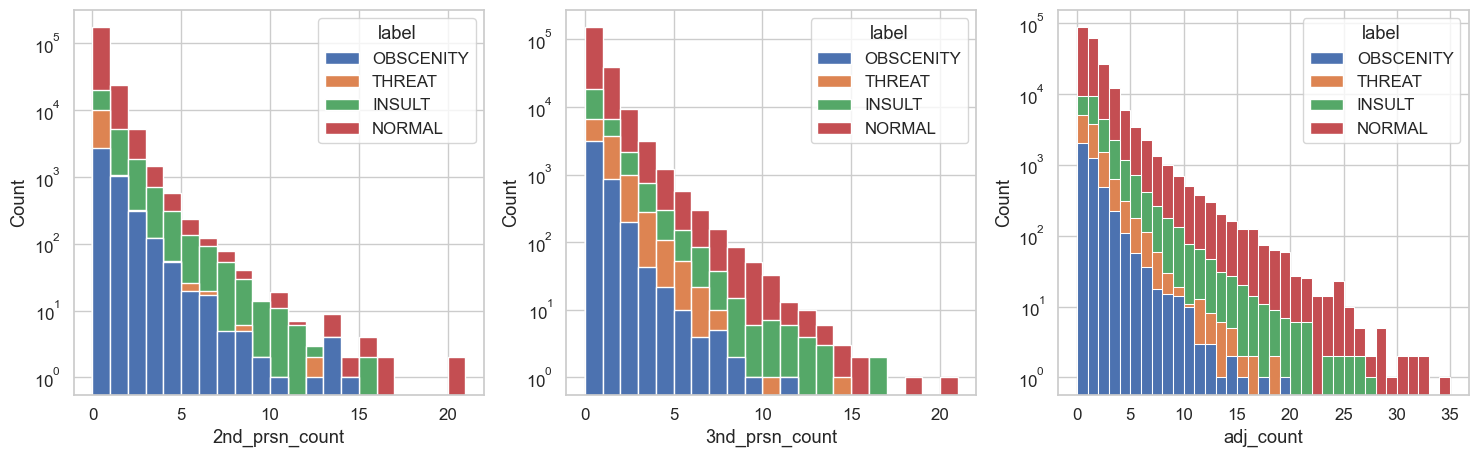

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs_flatten = axs.flatten()

for i, feature in enumerate(new_features):
    sns.histplot(df, x=feature, binwidth=1, hue="label", hue_order=categories, ax=axs_flatten[i], alpha=1)
    axs_flatten[i].set_yscale("log")

По графикам видно, что распределение признаков не нормально, проверим это тестом Шапиро:

In [49]:
def test_shapiro(sample, title):
    display(Markdown(f'**{title}**'))
    stat, pvalue = shapiro(sample)
    print(f'Распределение нормально: {pvalue > 0.05}')

test_shapiro(df['adj_count'], 'Прилагательные')
test_shapiro(df['2nd_prsn_count'], 'Местоимения 2 лица')
test_shapiro(df['3nd_prsn_count'], 'Местоимения 3 лица')

**Прилагательные**

Распределение нормально: False


**Местоимения 2 лица**

Распределение нормально: False


**Местоимения 3 лица**

Распределение нормально: False


Оценим зависимость численных признаков от признака токсичный/нетоксичный комментарий:

In [59]:
def test_mannwhitneyu(sample1, sample2, title):
    display(Markdown(f'**{title}**'))
    stat, pvalue = mannwhitneyu(sample1, sample2, alternative='less')
    print(f'Есть статистически значимое отличие: {pvalue < 0.05}, p: {pvalue:.5f}')
    if pvalue >= 0.05:
        return
    n1, n2 = len(sample1), len(sample2)
    mean_stat = n1 * n2 / 2
    std_stat = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_stat) / std_stat
    r = abs(z) / np.sqrt(n1 + n2)
    print(f'Размер эффекта: {'маленький' if r < 0.1 else 'средний' if r < 0.3 else 'большой'}, r={r:.3f}')

adj_toxic = df[~df['is_normal']]['adj_count']
adj_normal = df[df['is_normal']]['adj_count']
test_mannwhitneyu(adj_normal, adj_toxic, 'Анализ количества прилагательных')

prn2_toxic = df[~df['is_normal']]['2nd_prsn_count']
prn2_normal = df[df['is_normal']]['2nd_prsn_count']
test_mannwhitneyu(prn2_normal, prn2_toxic, 'Анализ количества местоимений 2 лица')

prn3_toxic = df[~df['is_normal']]['3nd_prsn_count']
prn3_normal = df[df['is_normal']]['3nd_prsn_count']
test_mannwhitneyu(prn3_normal, prn3_toxic, 'Анализ количества местоимений 3 лица')

**Анализ количества прилагательных**

Есть статистически значимое отличие: True, p: 0.00000
Размер эффекта: маленький, r=0.042


**Анализ количества местоимений 2 лица**

Есть статистически значимое отличие: True, p: 0.00000
Размер эффекта: маленький, r=0.076


**Анализ количества местоимений 3 лица**

Есть статистически значимое отличие: True, p: 0.00000
Размер эффекта: маленький, r=0.073


Оценим зависимость численных признаков от классов токсичности:

In [61]:
# Прилагательные между INSULT и остальными
adj_obs = df[df['label'] == 'OBSCENITY']['adj_count']
adj_ins = df[df['label'] == 'INSULT']['adj_count']
test_mannwhitneyu(adj_obs, adj_ins, 'Количество прилагательных: OBSCENITY < INSULT')

adj_trh = df[df['label'] == 'THREAT']['adj_count']
test_mannwhitneyu(adj_trh, adj_ins, 'Количество прилагательных: THREAT < INSULT')

# 2 лицо между INSULT и остальными
prn2_obs = df[df['label'] == 'OBSCENITY']['2nd_prsn_count']
prn2_ins = df[df['label'] == 'INSULT']['2nd_prsn_count']
test_mannwhitneyu(prn2_obs, prn2_ins, 'Количество местоимений 2 лица: OBSCENITY < INSULT')

prn2_thr = df[df['label'] == 'THREAT']['2nd_prsn_count']
test_mannwhitneyu(prn2_thr, prn2_ins, 'Количество местоимений 2 лица: THREAT < INSULT')

# 3 лицо между INSULT и остальными
prn3_obs = df[df['label'] == 'OBSCENITY']['3nd_prsn_count']
prn3_ins = df[df['label'] == 'INSULT']['3nd_prsn_count']
test_mannwhitneyu(prn3_obs, prn3_ins, 'Количество местоимений 3 лица: OBSCENITY < INSULT')

prn3_thr = df[df['label'] == 'THREAT']['3nd_prsn_count']
test_mannwhitneyu(prn3_thr, prn3_ins, 'Количество местоимений 3 лица: THREAT < INSULT')

**Количество прилагательных: OBSCENITY < INSULT**

Есть статистически значимое отличие: True, p: 0.00000
Размер эффекта: средний, r=0.105


**Количество прилагательных: THREAT < INSULT**

Есть статистически значимое отличие: True, p: 0.00000
Размер эффекта: средний, r=0.111


**Количество местоимений 2 лица: OBSCENITY < INSULT**

...

Есть статистически значимое отличие: True, p: 0.00000
Размер эффекта: средний, r=0.127


**Количество местоимений 3 лица: OBSCENITY < INSULT**

Есть статистически значимое отличие: True, p: 0.00000
Размер эффекта: маленький, r=0.057


**Количество местоимений 3 лица: THREAT < INSULT**

Есть статистически значимое отличие: False, p: 1.00000


 **Выводы:**
1. Существует стат. значимая зависимость в количестве прилагательных, местоимений 2 и 3 лица между токсичными и нормальными комментариями, но ее сила крайне низка
2. Для классов токсичных комментариев также существует стат. зависимость, причем: eсть небольшая зависимость в количестве прилагательных и местоимений 2 лица между классами THREAT и INSULT, также есть небольшая зависимость в количестве прилагательных между классами OBSCENITY и INSULT.


## Морфологический анализ, выводы:

1. Есть крайне слабая зависимость между токсичным/нормальными комментариями по количеству прилагательных и рассмотренных местоимений.
2. Есть небольшая зависимость между классами токсичности THREAT и INSULT по количеству местоимений 2 и прилагательных
3. Есть крайне слабая зависимость между классами NORMAL, THREAT, INSULT по наличию вокатива. Для класса OBSCENITY нулевую гипотезу о том что признаки независимы отвергуть не удалось.
4. Есть крайне слабая зависимость в наличии императива в зависимости от признака токсичный/нормальный.
5.  Есть крайне слабая зависимость в наличии экспрессивной пунктуации в зависимости от признака токсичный/нормальный.
6. Отличия по признаку наличия вокатива/имератива между токсичным/нормальными комментариями сильно меньше, чем отличия по признаку наличию мата.